<h1> Proyecto de Machine learning <h1>

### Realizado por:
#### - Maria Juliana Quintero Duque
#### - Maria José Salazar Jaramillo
#### - Santiago Villegas Restrepo


## Contexto

| Problema | Tipo de tarea | Área financiera |
|---|---|---|
| **Predicción de incumplimiento de tarjetas de crédito** | Clasificación binaria | Riesgo de crédito |
| **Valoración de perdidas por seguros de vehículos** | Regresión | Actuaría |

</br>

Ambos datasets provienen del **UCI Machine Learning Repository** ([archive.ics.uci.edu](https://archive.ics.uci.edu/)), un repositorio académico ampliamente utilizado, con datos reales y bien documentados.

---


# 1. Problema de Clasificación







## 1.1 Descripción del dataset: *Default of Credit Card Clients*

- **Fuente:** UCI Machine Learning Repository — Dataset ID `350`  
  URL: <https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients>
- **Donante:** I-Cheng Yeh (2009). *The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients.* Expert Systems with Applications, 36(2).
- **Licencia:** Creative Commons Attribution 4.0 (CC BY 4.0)
- **Observaciones:** 30 000 clientes de tarjetas de crédito de Taiwán (abril–septiembre 2005)
- **Variables predictoras:** 23
- **Valores faltantes:** ninguno



##Dominio del Problema:
El problema se encuentra en el sector financiero, específicamente en el área de riesgo de crédito. Busca analizar el comportamiento de clientes de tarjetas de crédito para identificar aquellos que podrían incumplir sus obligaciones de pago.

##Descripción y Tipo de Problema:
Se trata de un problema de clasificación binaria, cuyo objetivo es predecir si un cliente incurrirá o no en incumplimiento de pago (default) durante el siguiente período. La variable de salida toma dos posibles valores: 1, si el cliente incumple, y 0, si no incumple.

##Utilidad e Importancia:
La utilidad principal del modelo es anticipar el riesgo de incumplimiento de los clientes a partir de su información financiera y comportamiento de pago. Esto permite a las entidades financieras tomar decisiones más informadas sobre la concesión, administración y seguimiento del crédito. La propia UCI señala que, desde la perspectiva de la gestión del riesgo, conocer la probabilidad de default resulta especialmente valioso.

Un modelo de este tipo puede contribuir a identificar clientes con mayor riesgo antes de que ocurra el incumplimiento; reducir pérdidas financieras, al permitir estrategias preventivas de cobranza y seguimiento; mejorar la asignación del crédito, ajustando límites y condiciones según el nivel de riesgo; y optimizar la gestión de la cartera, diferenciando clientes según su probabilidad de incumplimiento.

## Relevancia en la Ingeniería Financiera
Su importancia en la Ingeniería Financiera radica principalmente en que el proyecto aborda directamente la gestión del riesgo de crédito y combina herramientas de estadística, programación y Machine Learning para apoyar la toma de decisiones financieras basadas en datos. Además, la predicción del default constituye una aplicación práctica de los modelos de credit scoring utilizados en el sector financiero; los cuales nos permiten comparar el poder predictivo de variables demográficas vs. de comportamiento (historial de pagos), y practicar el manejo de clases desbalanceadas, los cual es típico en riesgo de crédito.

## 1. Importaciones y configuración

In [ ]:

# Importaciones base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML / Preprocesamiento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score

# Utilidades
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 100)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Carga del dataset real (UCI via Pandas)

In [ ]:
data = pd.read_excel('/content/default of credit card clients.xls',
                  header=1)
df = data.copy()

print(f"Dimensiones: {df.shape}")
df.head(10)

Dimensiones: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,0,0,367965,412023,445007,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,0,-1,11876,380,601,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,0,0,11285,14096,12108,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,-1,-1,0,0,0,0,13007,13912,0,0,0,13007,1122,0,0


# DESCRIPCIÓN DE LAS VARIABLES

1. **default payment next month - Variable Objetivo:** su función es predecir si un cliente incurrirá o no en incumplimiento de pago (default) durante el siguiente período. La variable de salida toma dos posibles valores: 1, si el cliente incumple, y 0, si no incumple. Tipo de variable: binaria

2. LIMIT_BALL (X1):  Monto del crédito otorgado, en dólares Taiwaneses. Incluye el crédito individual y el crédito suplementario familiar; en Taiwan se otorgan tarjetas de crédito asociadas a la misma cuenta que son entregadas a familiares del titular. Tipo de variable: entero

3. **GENDER (X2):** indica el género del cliente, es una variable sociodemográfica categórica. Toma 1 = masculino y 2 = femenino. Tipo de variable: entero

4. **EDUCATION (X3):** indica el nivel educativo, es una variable sociodemográfica categórica. 1=posgrado, 2=pregrado, 3=Bachillerato, 4=otros. Esta variable sirve para medir el nivel socioeconómico y formación del cliente. Tipo de variable: entero

5. **MARRIAGE (X4):** indica el estado civile, es una variable sociodemográfica categórica. 1=Casado, 2=Soltero y 3= otros. Tipo de variable: entero

6. **AGE (X5):** indica la edad del cliente en años. es una variable sociodemográfica. Tipo de variable: entero

7. **HISTORIAL DE PAGOS (X6 - X11):** registra el historial pago mensual de septiembre a abril de 2005 en orden descendente en el tiempo:
- PAY_0 (X6): indica el pago de septiembre de 2005
- PAY_2 (X7): indica el pago de agosto de 2005
- PAY_3 (X8): indica el pago de julio de 2005
- PAY_4 (X9): indica el pago de junio de 2005
- PAY_5 (X10): indica el pago de mayo de 2005
- PAY_6 (X11): indica el pago abril de 2005

Donde -1 = Pago puntual, 1 = Retraso de 1 mes, 2 =retraso de 2 meses, ... 8 = retraso de 8 meses. Es una variable ordinal que indica el retraso del pago del crédito en cada periodo. Tipo de variable: entero

8. **Monto del estado de cuenta (X12-X17):** Refleja cuánto debía el cliente para cada uno de los seis meses en dólares Taiwaneses. Tipo de variable: entero
- BILL_AMT1 (X12): Estado de cuenta para septiembre de 2005
- BILL_AMT2 (X13): Estado de cuenta para agosto de 2005
- BILL_AMT3 (X14): Estado de cuenta para julio de 2005
- BILL_AMT4 (X15): Estado de cuenta para junio de 2005
- BILL_AMT5 (X16): Estado de cuenta para mayo de 2005
- BILL_AMT6 (X17): Estado de cuenta para abril de 2005

9. **Monto efectivamente pagado (X18 - X23):** refleja cuánto abonó el cliente frente a lo que debía en cada uno de los seis meses. Tipo de variable: entero
- PAY_AMT1 (X18): Monto efectivamente pagado en septiembre de 2005
- PAY_AMT2 (X19): Monto efectivamente pagado en agosto de 2005
- PAY_AMT3 (X20): Monto efectivamente pagado en julio de 2005
- PAY_AMT4 (X21): Monto efectivamente pagado en junio de 2005
- PAY_AMT5 (X22): Monto efectivamente pagado en mayo de 2005
- PAY_AMT6 (X23): Monto efectivamente pagado en abril de 2005

Estas variables permiten ilustrar una linea de tiempo del comportamiento de pago de cada cliente durante 6 meses, las cuales son claves para determinar el pago mínimo, la tendencia de endeudamiento y la posible persistencia de atrasos.


In [ ]:
df = data.copy()
print(f"Dimensiones: {df.shape}")
df.head(10)

Dimensiones: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,0,0,367965,412023,445007,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,0,-1,11876,380,601,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,0,0,11285,14096,12108,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,-1,-1,0,0,0,0,13007,13912,0,0,0,13007,1122,0,0


In [ ]:
df.drop(columns=["ID"], inplace=True)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


Como la variable de salida toma dos valores; este es un problema de clasificación (binario)

In [ ]:
df["default payment next month"].unique()

array([1, 0])

Está desbalanceada: Solo el 22.12% de los clientes incurrirá en impago el próximo periodo (tomando el valor de 1); el otro 77.88% pagará cumplidamente (tomando el valor de 0)

In [ ]:
df[df["default payment next month"] == 1].shape

(6636, 24)

In [ ]:
df[df["default payment next month"] == 0].shape

(23364, 24)

## 3. Inspección inicial y limpieza básica

In [ ]:
# Tipos de datos y conteo de nulos
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_nulls": df.isna().sum(),
    "n_unique": df.nunique()
}).sort_index()

display(info)
display(df.describe())


,dtype,n_nulls,n_unique
AGE,int64,0,56
BILL_AMT1,int64,0,22723
BILL_AMT2,int64,0,22346
BILL_AMT3,int64,0,22026
BILL_AMT4,int64,0,21548
BILL_AMT5,int64,0,21010
BILL_AMT6,int64,0,20604
EDUCATION,int64,0,7
LIMIT_BAL,int64,0,81
MARRIAGE,int64,0,4


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


# Análisis Inspección Inicial

1. Default payment next month: la variable objetivo sólo puede tomar dos valores (1 o 0), tiene 30.000 registros de los cuáles 23364 corresponden a 0 y 6636 a 1.

2. LIMIT_BAL: cuenta con 30.000 registros, sin valores faltantes. La variable toma 81 valores y el monto de crédito otorgado oscila entre un mínimo de 10.000 y un  máximo de 1.000.000. El monto promedio otorgado es de $167.484, con una desviación estandar de  129.747 lo que indica una alta dispersión en los cupos asignados.

3. SEX: cuenta con 30.000 registros, sin valores faltantes. La variable solo puede tomar dos valores.

4. EDUCATION: cuenta con 30.000 registros, sin valores faltantes. La variable puede tomar 7 valores, de los cuáles solo tres han sido identificados, el resto no ha sido posible identificar.

5. MARRIAGE: cuenta con 30.000 registros, sin valores faltantes. La variable puede tomar 4 valores, de los cuáles solo tres han sido identificados, el resto no ha sido posible identificar.

6. AGE: cuenta con 30.000 registros, sin valores faltantes. La variable toma 56 valores. La edad mínima son 21 años y la máxima son 79. La edad promedio oscila en 35 años, con una desviación estandar de 9 años.

7. Las variables PAY_# cuentan con 30.000 registros, sin valores faltantes. Pueden tomar entre 10 y 11 valores, dependiendo del retraso mensual del pago. Estas serán analizadas con mayor profundidad con los histogramas.

8. BILL_AMT1: cuenta con 30.000 registros, sin valores faltantes. La variable toma 22723 valores. El estado de cuenta oscila en un mínimo de -165.580 y un máximo de 964.511. El monto promedio de estado de cuenta para el mes de septiembre de los clientes es de 51.223, con una desviación estandar de 73.635 lo que indica una alta dispersión en los estados de cuenta.

9. BILL_AMT2: cuenta con 30.000 registros, sin valores faltantes. La variable toma 22.346 valores. El estado de cuenta oscila entre un mínimo de -69.777 y un máximo de 983.931. El monto promedio de estado de cuenta para el mes de agosto de los clientes es de 49.179, con una desviación estandar de 71.173 lo que indica una alta dispersión en los estados de cuenta.

10. BILL_AMT3: cuenta con 30.000 registros, sin valores faltantes. La variable toma 22.026 valores. El estado de cuenta oscila entre un mínimo de -1.572640e+05 y un máximo de 1.664089e+06. El monto promedio de estado de cuenta para el mes de julio de los clientes es de 4.701315e+04, con una desviación estandar de 6.934939e+04.

11. BILL_AMT4: cuenta con 30.000 registros, sin valores faltantes. La variable toma 21.548 valores. El estado de cuenta oscila entre un mínimo de -170.000 y un máximo de 891.586. El monto promedio de estado de cuenta para el mes de junio de los clientes es de 43.262, con una desviación estandar de 64.332.

12.  BILL_AMT5: cuenta con 30.000 registros, sin valores faltantes. La variable toma 21.010 valores. El estado de cuenta oscila entre un mínimo de -81.334 y un máximo de 927.171. El monto promedio de estado de cuenta para el mes de mayo de los clientes es de 40.311, con una desviación estandar de 60.797.

13. BILL_AMT6: cuenta con 30.000 registros, sin valores faltantes. La variable toma 20.604 valores. El estado de cuenta oscila entre un mínimo de -339.603 y un máximo de 961.664. El monto promedio de estado de cuenta para el mes de abril de los clientes es de 38.871, con una desviación estandar de 59.554.

A partir de los estados de cuenta se identifica que a medida que avanza los meses, el monto promedio de cuenta aumenta así cómo la dispersión de estas. Lo que podría estar explicado por un aumento en la deuda o retrasos en los pagos.

14. PAY_AMT1: cuenta con 30.000 registros, sin valores faltantes. La variable toma 7.943 valores. El monto efectivamente pagado oscila entre un mínimo de 0 y un máximo de 873.552. El monto promedio de abono para el mes de septiembre de los clientes es de 5.663, con una desviación estandar de 16.563 lo que indica una alta dispersión en los abonos entre los clientes.

15. PAY_AMT2: cuenta con 30.000 registros, sin valores faltantes. La variable toma 7.899 valores. El monto efectivamente pagado oscila entre un mínimo de 0 y un máximo de 	1.684259e+06. El monto promedio de abono para el mes de agosto de los clientes es de 5.921163e+03, con una desviación estandar de 2.304087e+04 lo que indica una alta dispersión en los abonos entre los clientes.

16. PAY_AMT3: cuenta con 30.000 registros, sin valores faltantes. La variable toma 7.518 valores. El monto efectivamente pagado oscila entre un mínimo de 0 y un máximo de 	896.040.. El monto promedio de abono para el mes de julio de los clientes es de 5.225, con una desviación estandar de 217.606 lo que indica una alta dispersión en los abonos entre los clientes.

17. PAY_AMT4: cuenta con 30.000 registros, sin valores faltantes. La variable toma 6.937 valores. El monto efectivamente pagado oscila entre un mínimo de 0 y un máximo de 621.000. El monto promedio de abono para el mes de junio de los clientes es de 4.826, con una desviación estandar de 15.666 lo que indica una alta dispersión en los abonos entre los clientes.

18. PAY_AMT5: cuenta con 30.000 registros, sin valores faltantes. La variable toma 6.897 valores. El monto efectivamente pagado oscila entre un mínimo de 0 y un máximo de 426.529. El monto promedio de abono para el mes de mayo de los clientes es de 4.799, con una desviación estandar de 15.278 lo que indica una alta dispersión en los abonos entre los clientes.

19. PAY_AMT6: cuenta con 30.000 registros, sin valores faltantes. La variable toma 6.939valores. El monto efectivamente pagado oscila entre un mínimo de 0 y un máximo de 528.666. El monto promedio de abono para el mes de abril de los clientes es de 5.215, con una desviación estandar de 17.777 lo que indica una alta dispersión en los abonos entre los clientes.

Se logra identificar como a medida que el tiempo avanza, los pagos promedios se hacen menores así cómo los pagos máximos, la dispersión entre abonos también cada vez se hace mayor. Esto podría estar explicado por una menor capacidad o retrasos en los pagos.




In [ ]:
# Limpieza mínima: eliminar duplicados exactos si existieran
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)
print(f"Filas eliminadas por duplicados: {n_before - n_after}")
df.head()

Filas eliminadas por duplicados: 35


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


Se eliminaron en total 35 filas por duplicados.

## 1.4. Análisis Exploratorio de Datos (EDA)

### 1.4.1 Distribuciones de variables (histogramas)

In [ ]:
# Variable objetivo
target = "default payment next month"

# Variables categóricas
categorical_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

# Variables numéricas: todas las demás, excepto las categóricas y la variable objetivo
numeric_cols = [
    col for col in df.columns
    if col not in categorical_cols + [target, "ID"]
]

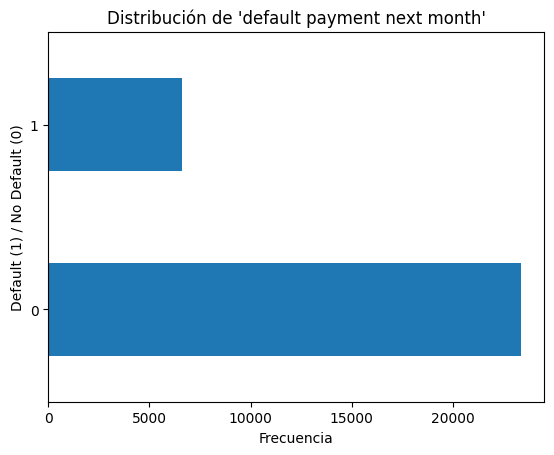

In [ ]:
default_payment_next_month = df['default payment next month'].value_counts()
default_payment_next_month.plot(kind='barh')
plt.title("Distribución de 'default payment next month'")
plt.xlabel("Frecuencia")
plt.ylabel("Default (1) / No Default (0)")
plt.show()

A partir del diagrama de barras se observa la distribución de la variable objetivo sobre las 30.000 observaciones. La categoria 0 (no default) concentra la mayoria de los casos en un 77.88% mientras que la categoría 1 (default) representa el 22.12% restante. Esta diferencia evidencia un desbalance de clases.

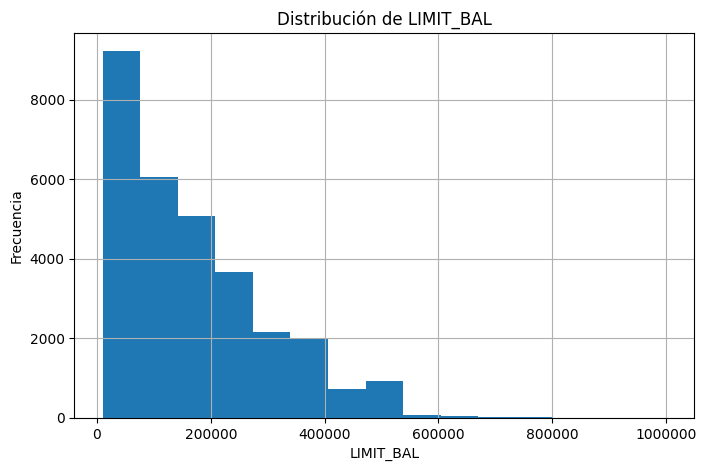

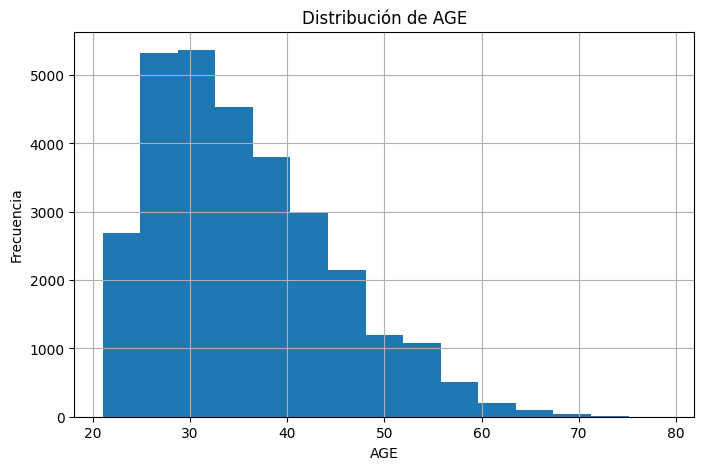

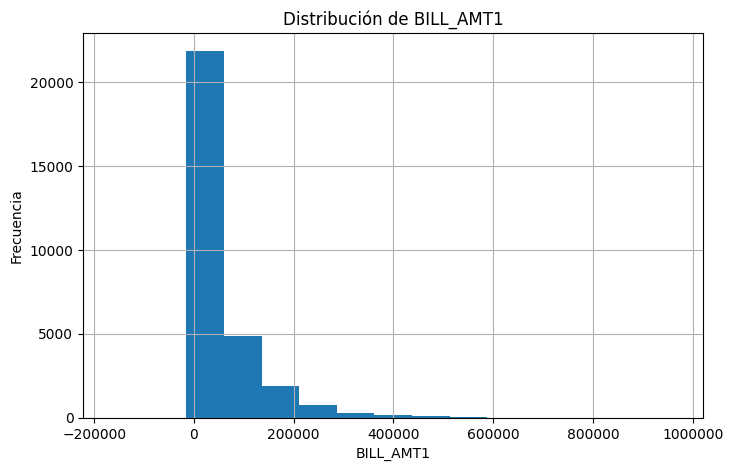

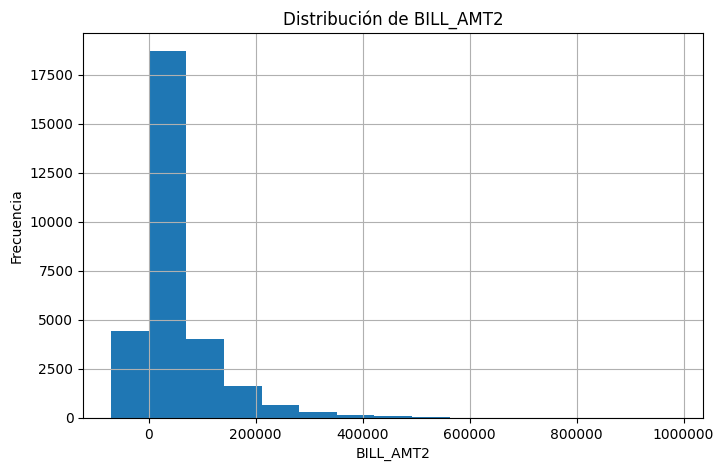

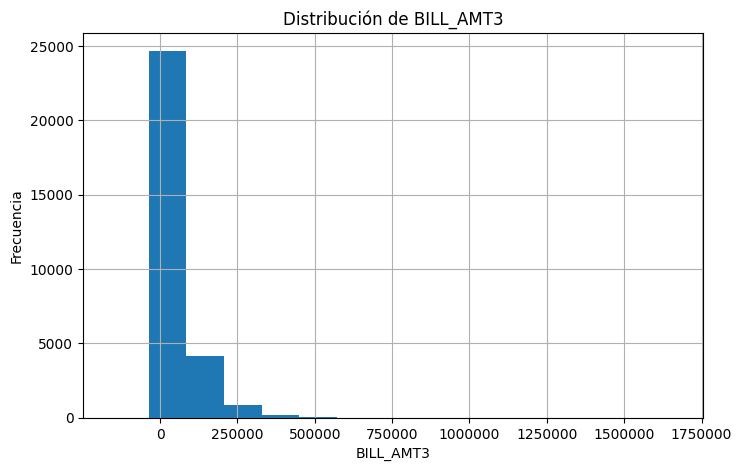

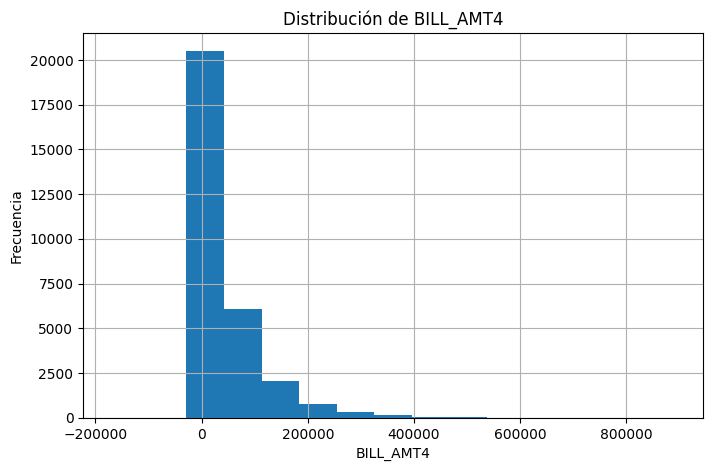

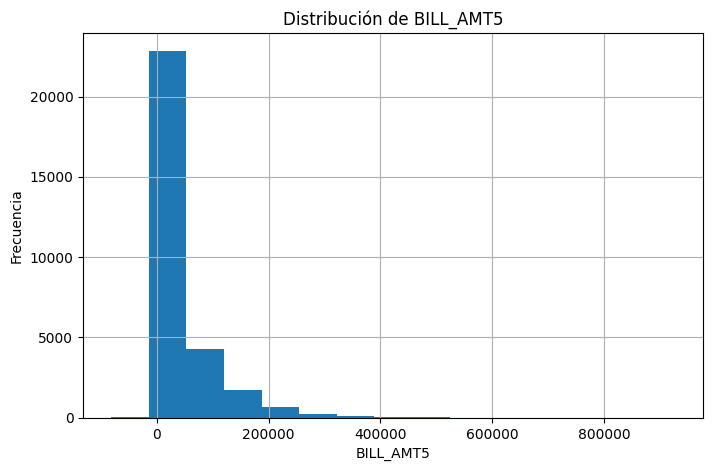

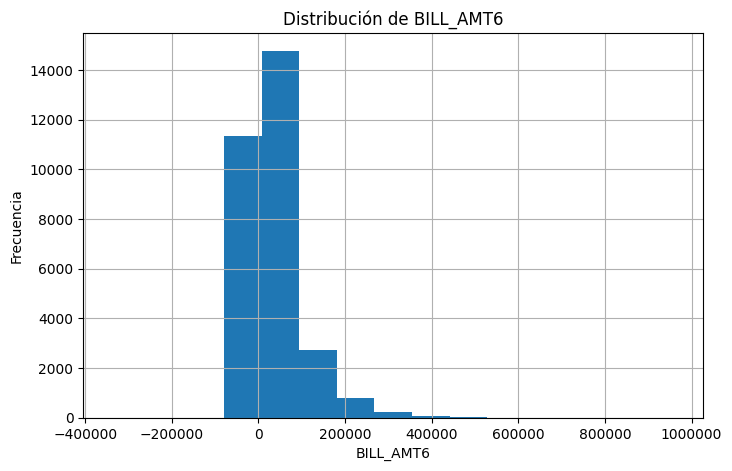

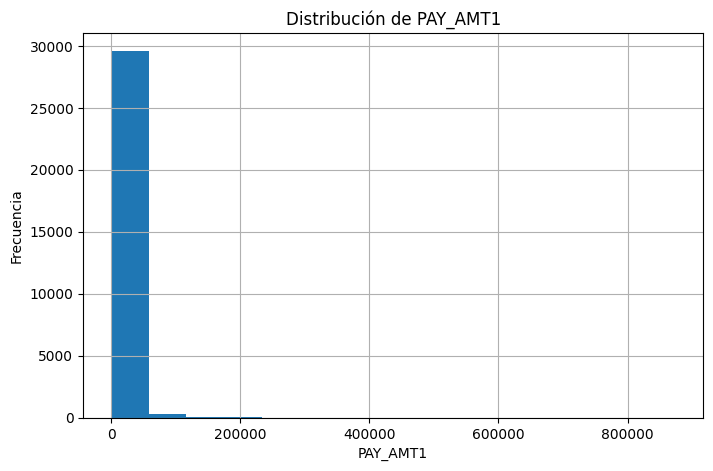

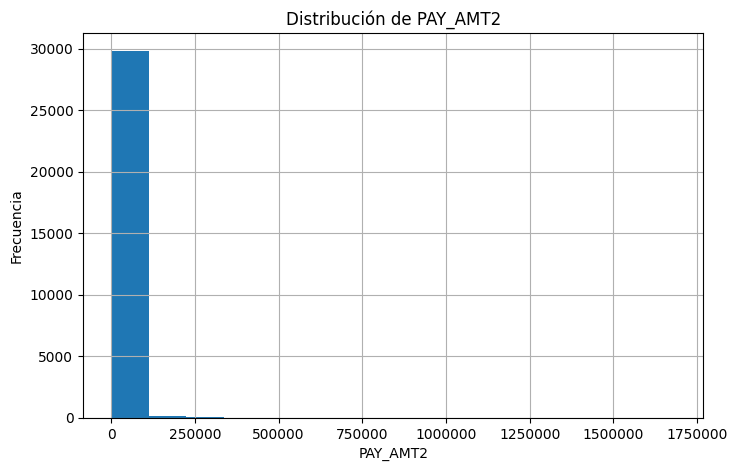

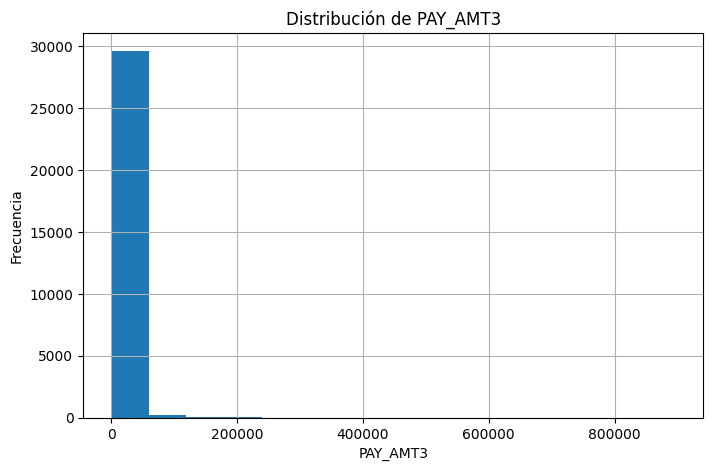

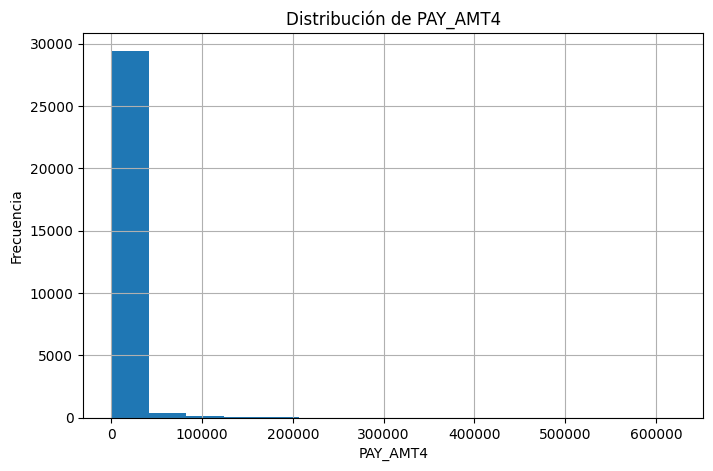

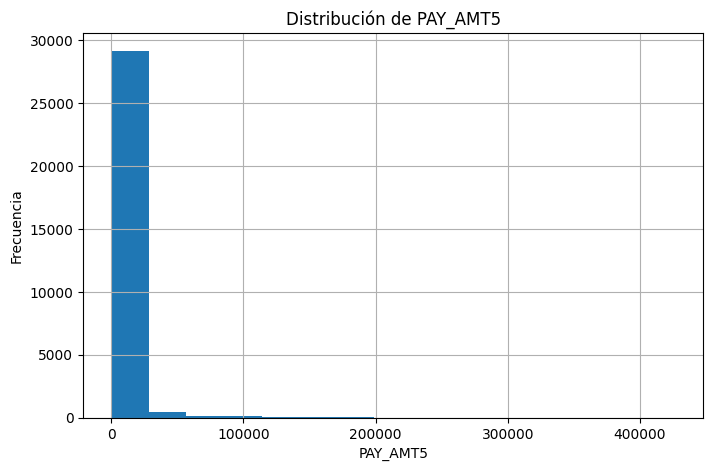

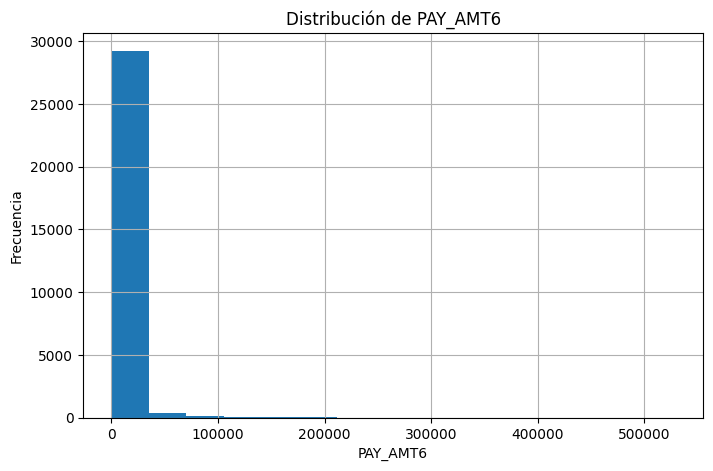

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))

    df[col].hist(bins=15)

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.ticklabel_format(style='plain', axis='x')

    plt.show()

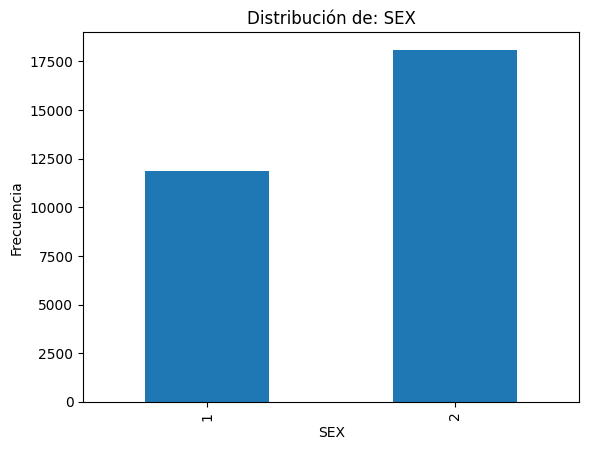

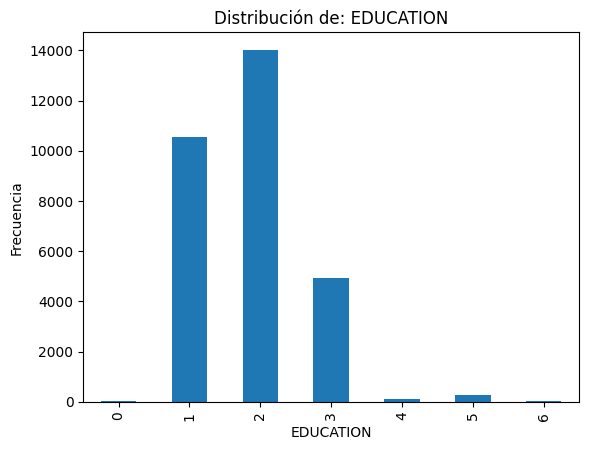

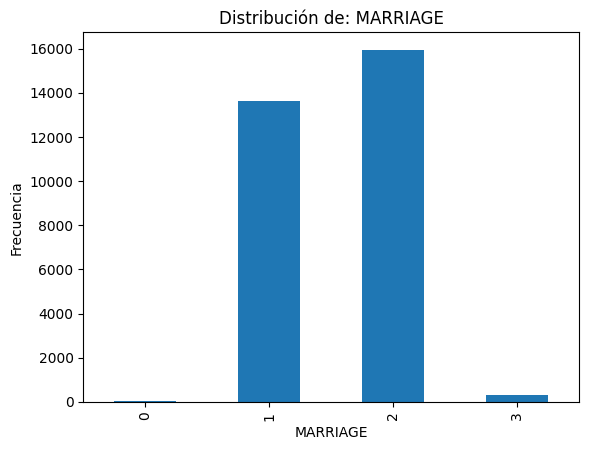

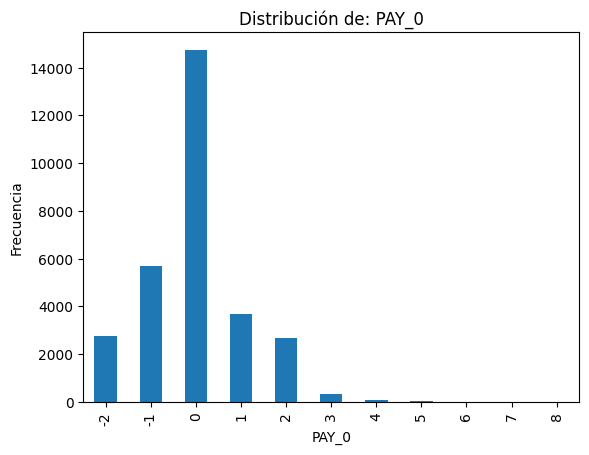

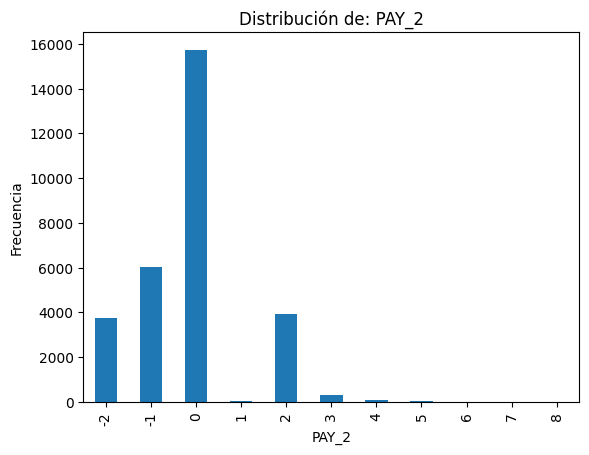

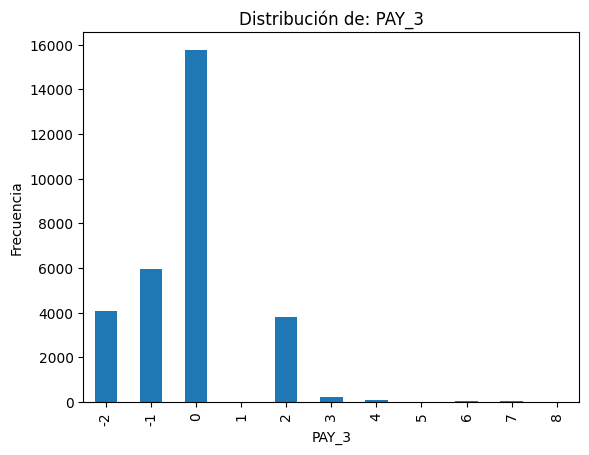

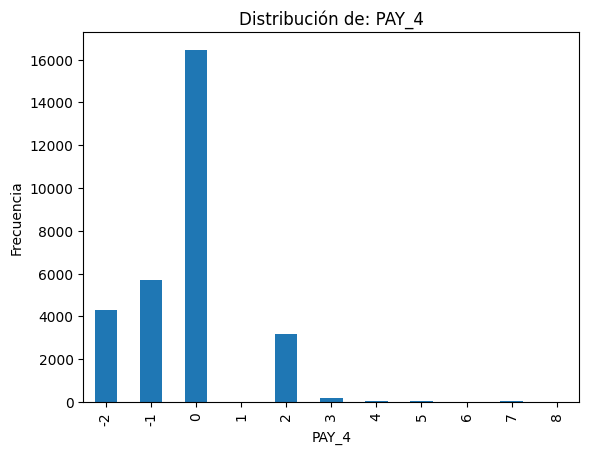

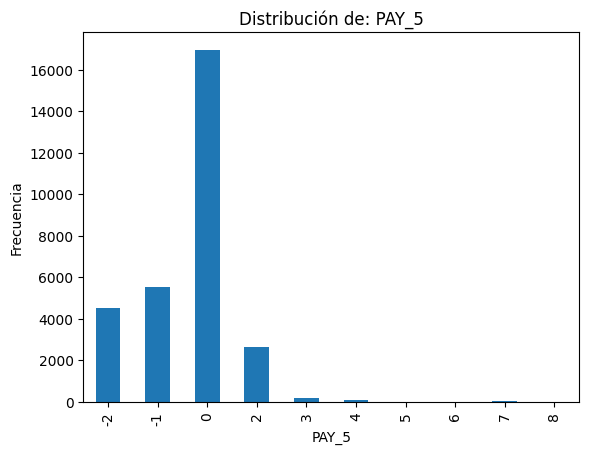

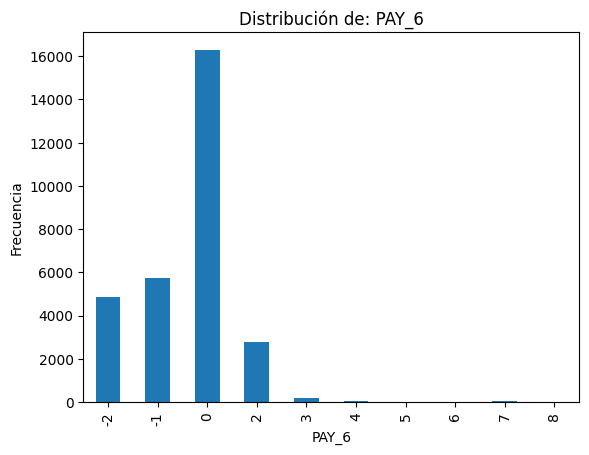

In [ ]:
for col in categorical_cols:
    plt.figure()
    df[col].value_counts().sort_index().plot(kind="bar")
    plt.title(f"Distribución de: {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

# Análisis Histogramas y diagramas de barras

**Limit ball:** el histograma confirma una distribución asimétrica hacia la derecha, es decir, la mayoría de clientes tienen cupos de créditos bajos, concentrados principalmente entre 0 y 200.000, solo un grupo muy reducido de clientes con mayor solvencia o antiguedad goza de cupos superiores.

**Age:** se evidencia una concentración de clientes en edades entre los 25 y 35. Los clientes más jovenes tienen 20 años y los más antiguos 75 años aproximadamente.

**BILL_AMT1 a BILL_AMT6:** las seis variables de monto de estado de cuenta muestran un comportamiento consistente mes a mes, distribuciones con fuerte sesgo a la derecha donde la mayoría de clientes muestran saldos bajos cercanos a cero y solo una pequeña porción de clientes presenta saldos elevados aproximadamente hasta 700.00. Algunos valores negativos corresponden a saldos a favor. Por último, la distribución evidencia una estabilidad en los patrones de los estados de cuenta de los clientes.  

**PAY_AMT1 a PAY_AMT6:** estas variables muestran una distribución sesgada a la derecha, donde se evidencia que la mayoría de los clientes realizan pagos muy bajos, mientras que un grupo minoritario efectúa pagos considerablemente altos. Este patrón sugiere que buena parte de la cartera realiza pagos mínimos en lugar de cancelar todo su saldo.


**SEX:** en la variable sex se evidencia una mayor proporción de clientes de género femenino frente a clientes de género masculino, lo que indica que la cartera de clientes está compuesta mayoritariamente por mujeres.

**EDUCATION:** en esta variable se evidencia que la mayoría de los clientes cuentan con estudios universitarios, seguidos por quienes tienen estudios de posgrados y, en menor medida, por quienes cursaron hasta bachillerato (high school). El resto de clientes se agrupa en la categoría “otros”, representando una minoría dentro del total.

**MARRIAGE**: se evidencia una mayor proporción de clientes solteros respecto a clientes casados. El resto se agrupa en la categoría “otros”

**PAY_0,2,3,4,5 y 6:**  la variable pay muestra que la mayoría de clientes se concentra en las categorías -2, -1, 0 y 2, es decir sin atraso de pago, mientras que la frecuencia de atrasos disminuye de forma marcada a partir de 1 mes de retraso, y los retrasos severos resultan prácticamente marginales. Cabe resaltar que los valores -2 y 0 no están definidos explícitamente.


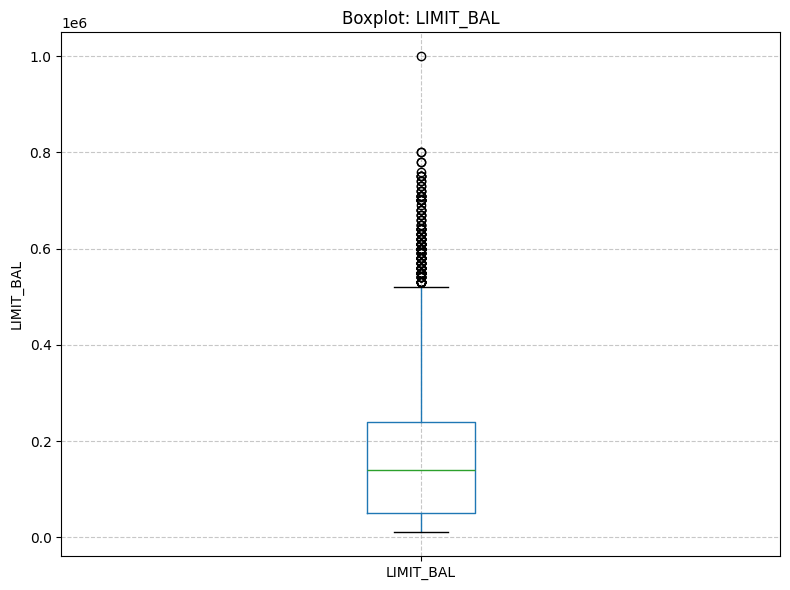

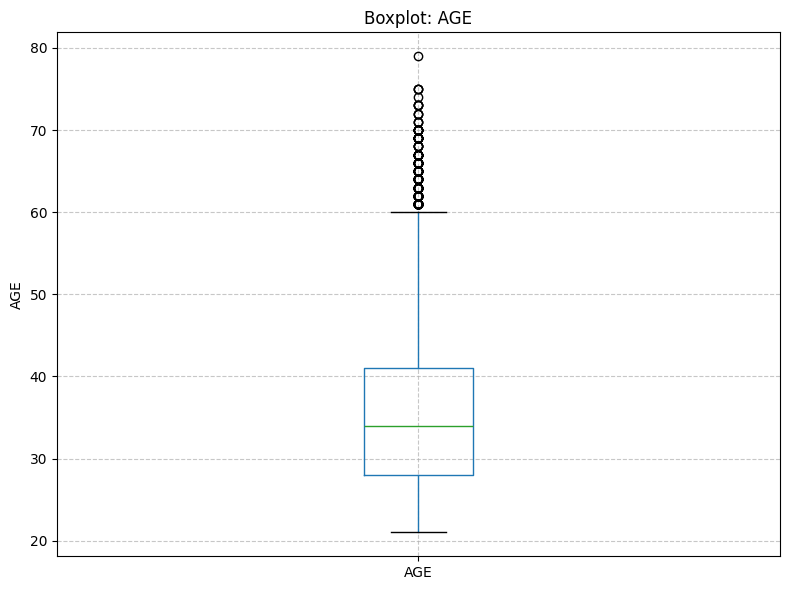

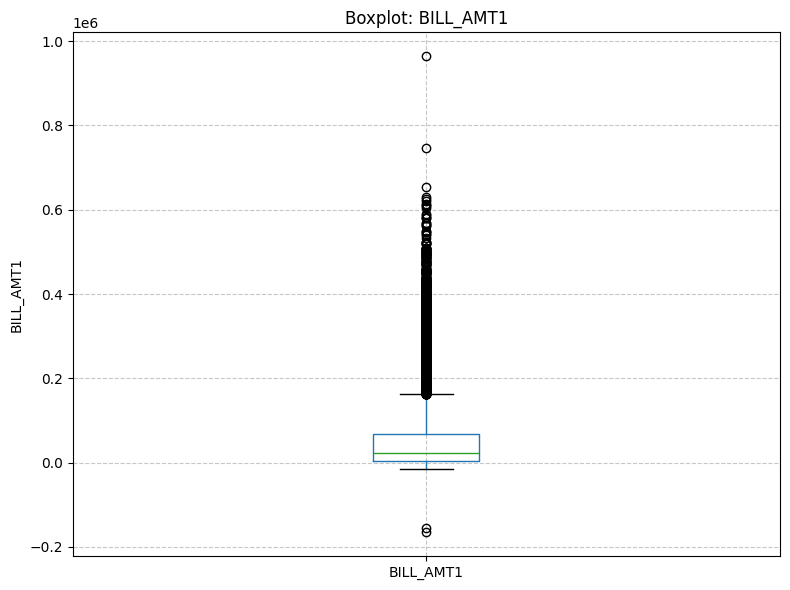

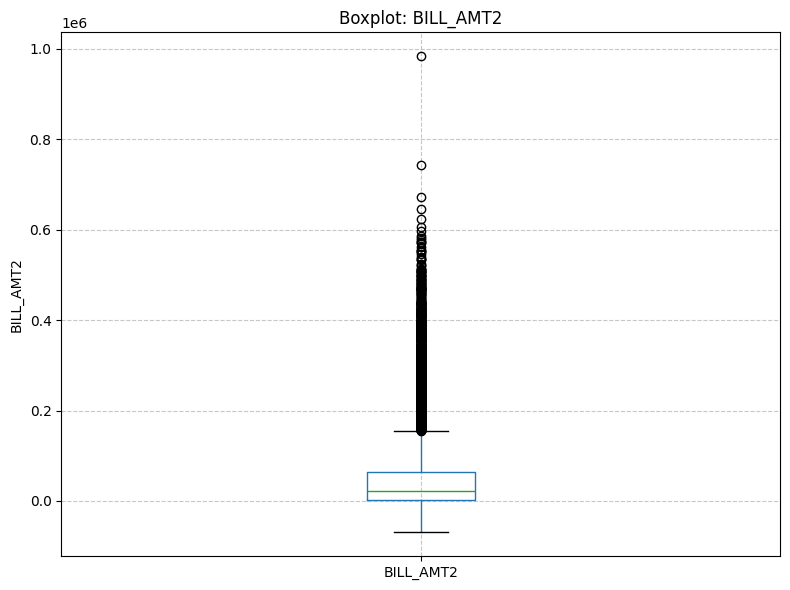

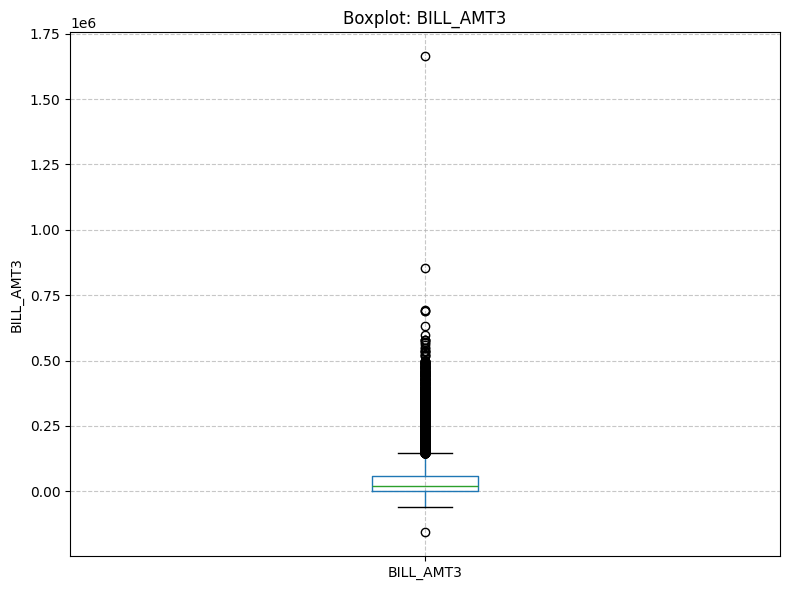

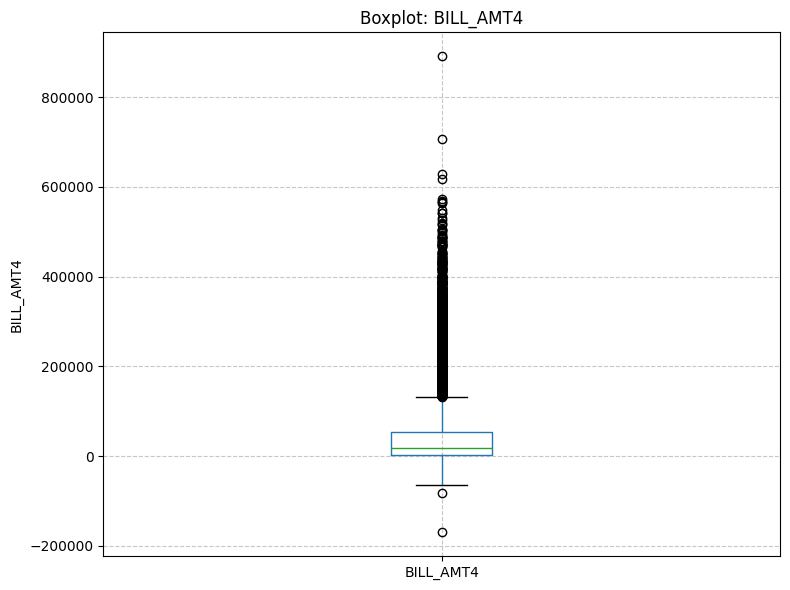

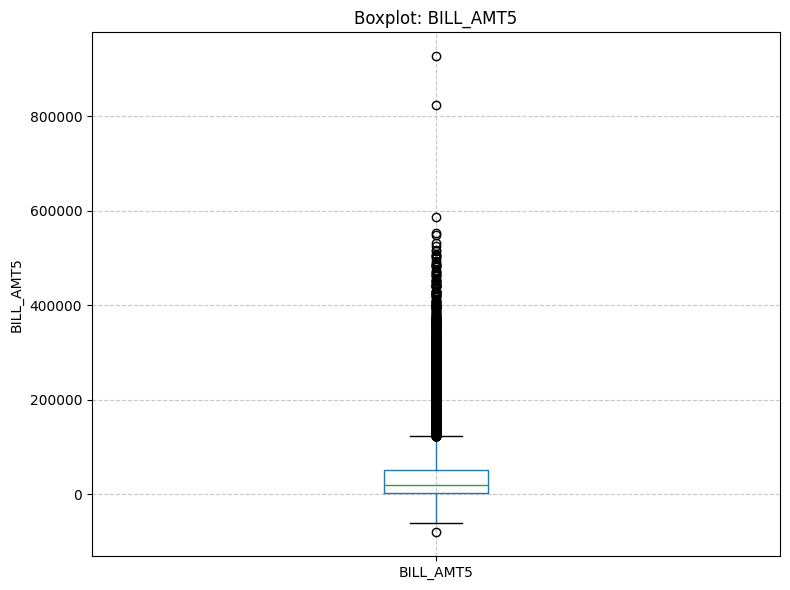

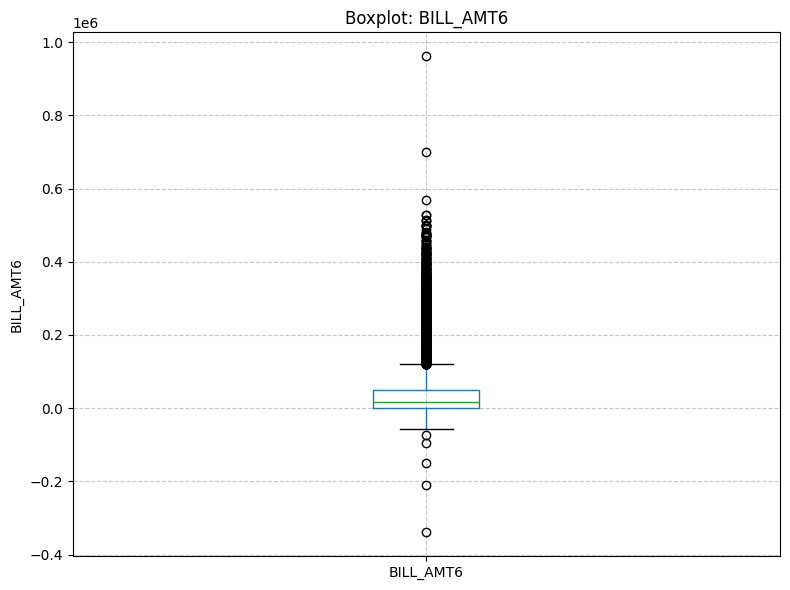

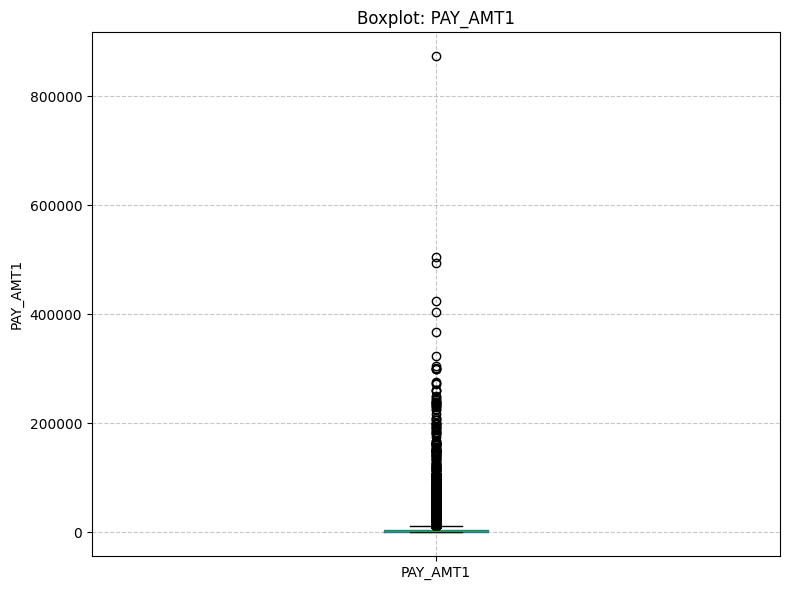

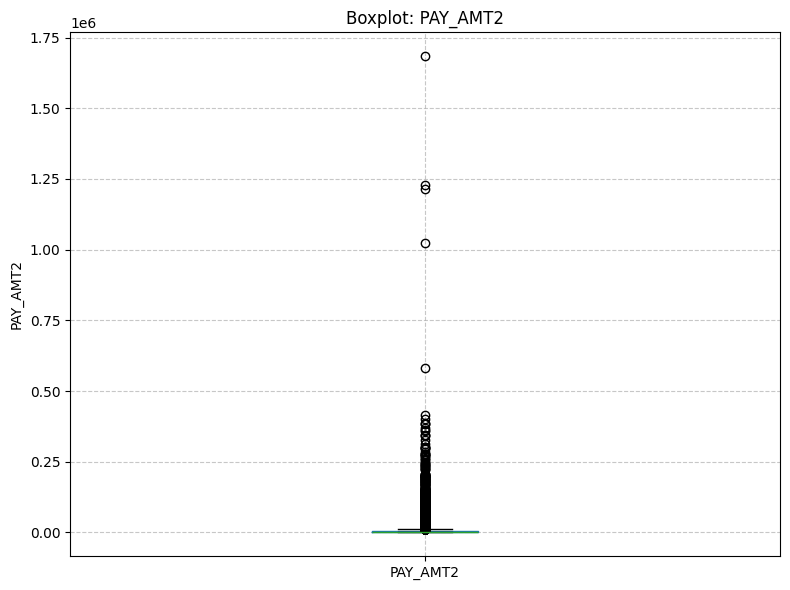

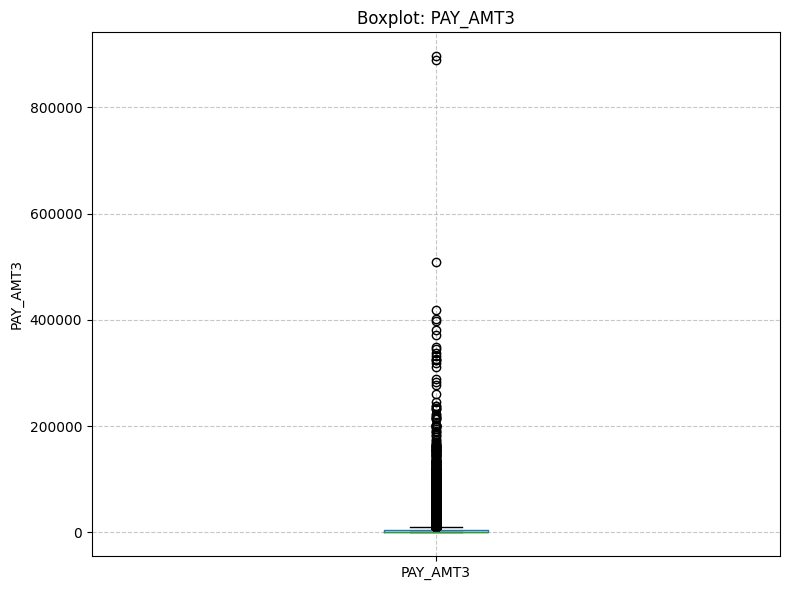

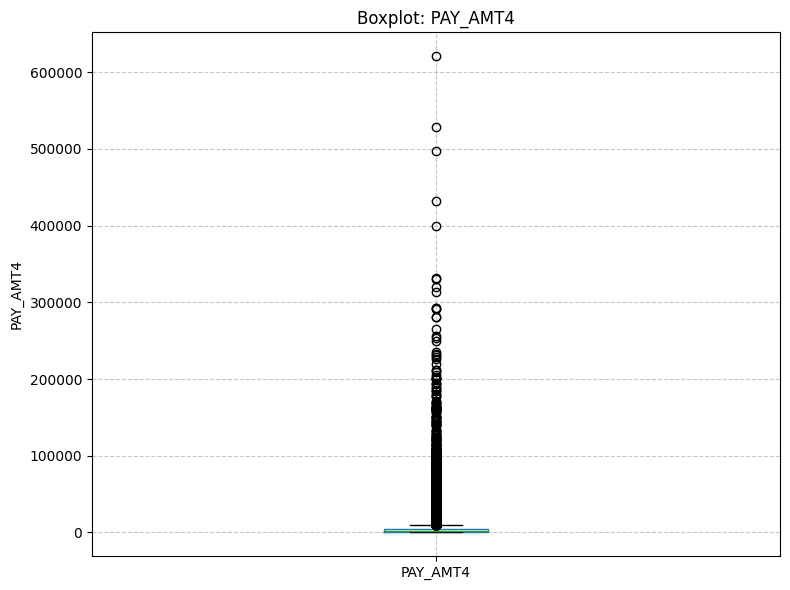

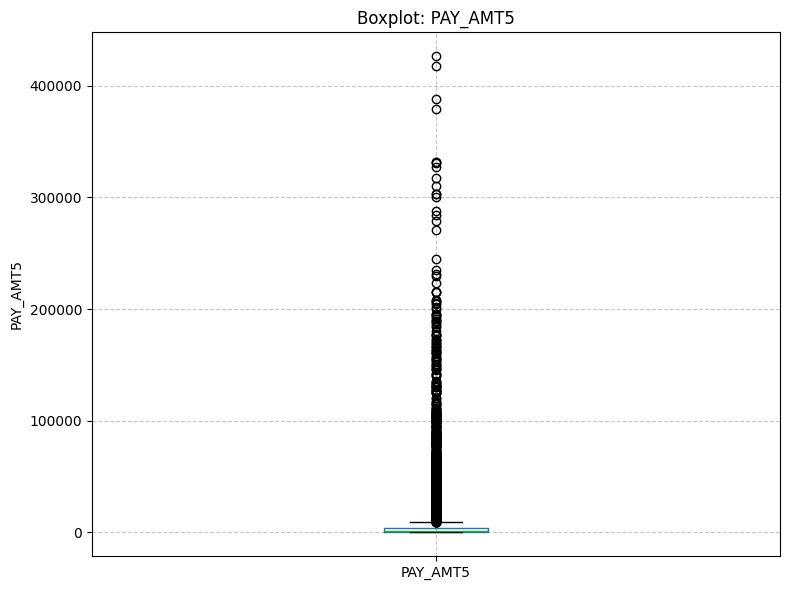

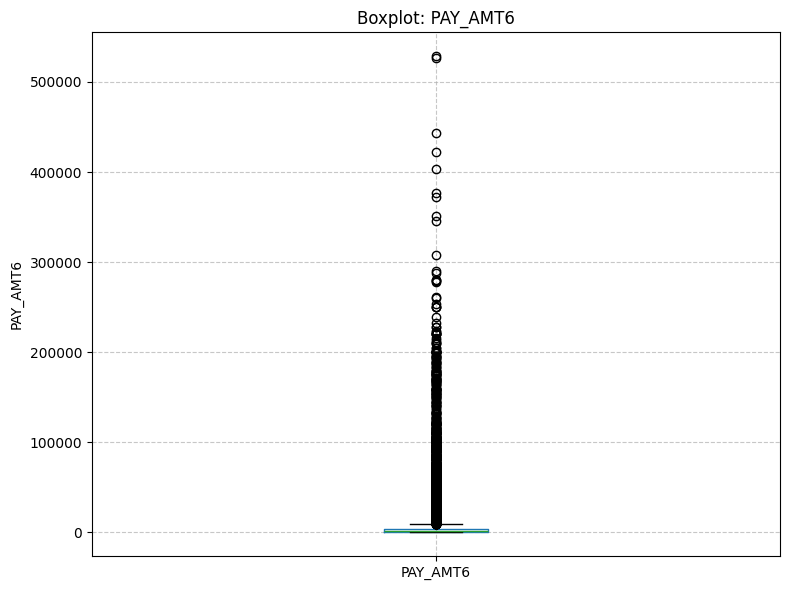

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    df.boxplot(column=col)
    plt.title(f"Boxplot: {col}")
    plt.ylabel(col)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

### Interpretación de las variables numéricas:

- **LIMIT_BAL:** La mayoría de los clientes tiene cupos de crédito bajos o intermedios (la mitad se ubica entre 50.000 y 240.000 NT$), mientras que unos pocos cuentan con cupos considerablemente más altos, llegando hasta 1.000.000. Estos aparecen como valores atípicos superiores, aunque en una proporción reducida.

- **AGE:** La edad de los clientes se concentra principalmente entre los 28 y 41 años, con una mediana de 34. Se observan algunos valores atípicos superiores correspondientes a clientes de edad avanzada, hasta los 79 años.

- Montos adeudados **(BILL_AMT1 a BILL_AMT6):** Todas presentan un comportamiento muy similar entre sí, con distribuciones fuertemente asimétricas hacia la derecha. La mayoría de los clientes mantiene saldos moderados (medianas cercanas a los 17.000–22.000 NT$), pero existe un grupo considerable de clientes con deudas mucho más altas, que aparecen como valores atípicos superiores en cerca del 8% de los casos. Adicionalmente, se identifican valores negativos, los cuales corresponden a saldos a favor del cliente (pagos en exceso o notas crédito) y no a errores de registro.

- Montos pagados **(PAY_AMT1 a PAY_AMT6):** Presentan la asimetría más marcada de todo el conjunto de datos. La mayoría de los clientes realiza pagos relativamente bajos (medianas entre 1.500 y 2.100 NT$). hay un porcentaje bajo de las observaciones se identifican como valores atípicos superiores en cada uno de los seis periodos.

Los valores atípicos identificados no se eliminan, ya que corresponden a clientes reales con comportamientos de crédito extremos pero legítimos (cupos altos, deudas elevadas o pagos grandes). En un contexto de riesgo crediticio estos casos son precisamente los de mayor interés, por lo que removerlos implicaría perder información relevante para el modelo.

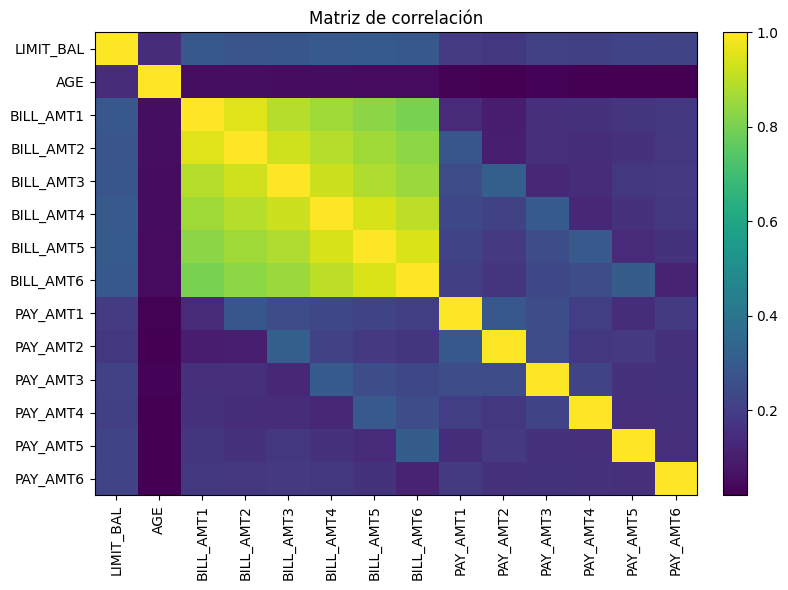

In [ ]:
corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(8,6))
im = plt.imshow(corr, aspect='auto', interpolation='nearest')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Matriz de correlación")
plt.xticks(ticks=np.arange(len(numeric_cols)), labels=numeric_cols, rotation=90)
plt.yticks(ticks=np.arange(len(numeric_cols)), labels=numeric_cols)
plt.tight_layout()
plt.show()

A partir de la matriz anterior e logra evidenciar una muy alta correlación entre todas las variables de BILL_AMT (las cuales indican el monto de factura mensual; es decir, el monto del estado de cuenta o el monto adeudado cada mes). Se está midiendo el mismo fenómeno a través del tiempo, por lo que se decide tomar periodicidades más alejadas para evaluar su impacto diferenciado (BILL_AMT1, BILL_AMT3, BILL_AMT6). Por lo que se procede con la eliminación de las variables BILL_AMT2, BILL_AMT4, BILL_AMT5.

In [ ]:
df.drop(columns=["BILL_AMT2", "BILL_AMT4", "BILL_AMT5"], inplace=True)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT3,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,689,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,2682,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,13559,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,49291,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,35835,19131,2000,36681,10000,9000,689,679,0


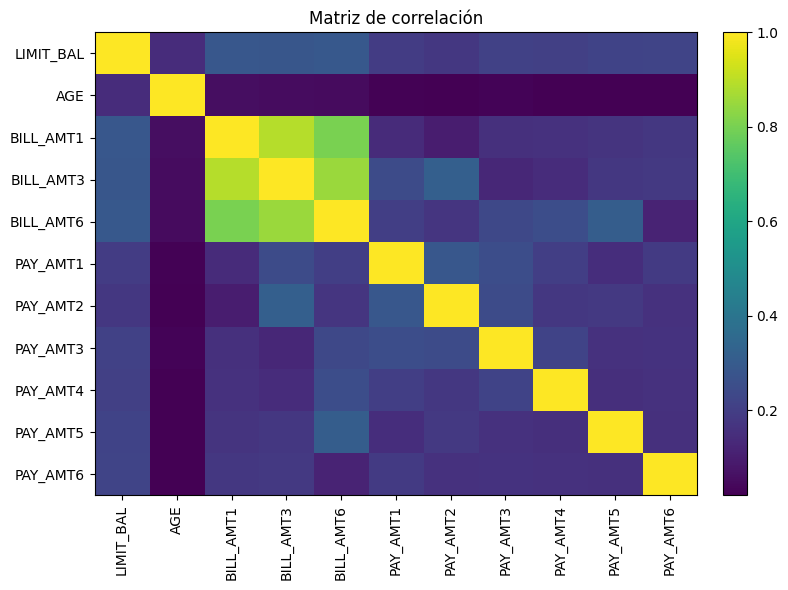

In [ ]:
numeric_cols = [
    col for col in df.columns
    if col not in categorical_cols + [target, "ID"]
]

corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(8,6))
im = plt.imshow(corr, aspect='auto', interpolation='nearest')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Matriz de correlación")
plt.xticks(ticks=np.arange(len(numeric_cols)), labels=numeric_cols, rotation=90)
plt.yticks(ticks=np.arange(len(numeric_cols)), labels=numeric_cols)
plt.tight_layout()
plt.show()

En esta nueva matriz de correlación se continúa evidenciando una dependencia lineal fuerte entre las tres variables de BILL_AMT, pero ya en una menor proporción. Se decide continuar trabajando con estas tres variables para lograr evidenciar el impacto del valor adeudado del cliente a diferentes plazos.

## 1.5 División Train/Test y Pipeline de Preprocesamiento

In [ ]:
X = df.drop(columns=["default payment next month"])
y = df["default payment next month"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = X_train.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_features)],
    remainder="drop"
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("logreg", LogisticRegression(max_iter=200, C=1, class_weight="balanced"))
])

clf

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LIMIT_BAL', 'SEX',
                                                   'EDUCATION', 'MARRIAGE',
                                                   'AGE', 'PAY_0', 'PAY_2',
                                                   'PAY_3', 'PAY_4', 'PAY_5',
                                                   'PAY_6', 'BILL_AMT1',
                                                   'BILL_AMT3', 'BILL_AMT6',
                                                   'PAY_AMT1', 'PAY_AMT2',
                                                   'PAY_AMT3', 'PAY_AMT4',
                                                   'PAY_AMT5', 'PAY_AMT6'])])),
                ('logreg',
                 LogisticRegression(C=1, class_weight='balanced',
                                    max_iter=200))])

Se hizo un split estratificado (Con estratificado se refiere a hacer el split manteniendo aproximadamente la misma proporción de clases que existe, para no modificar las proporciones), la division de los datos fue 80% de entrenamiento y 20% de test. Garantizando que no hay fuga de información, osea que el modelo vea datos que no deberia de haber visto, en sentido de que se haga el test con información con la que se entrenó. Con todos estas adaptaciones para poder ajustar un modelo correctamente se crea este encadenamiento de pasos que es el pipeline: Imputa medianas -> escala -> Realiza la regresion logistica. Asegurando que el proceso sea metodologicamente correcto y reproducible.

## 6. Validación Cruzada Estratificada (K-Folds)

In [ ]:

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

cv_results = cross_validate(
    clf, X, y, cv=cv, scoring=scoring, return_train_score=False, n_jobs=None
)

cv_df = pd.DataFrame(cv_results)
display(cv_df.describe().T[["mean", "std"]].round(4))


,mean,std
fit_time,0.3061,0.0804
score_time,0.0468,0.0330
test_f1,0.4765,0.0140
test_precision,0.3798,0.0111
test_recall,0.6395,0.0232


Se aplicó la función StratifiedKFold con 10 particiones (K) sobre el dataset, con el proposito de la estabilidad del modelo antes de ver la evaluación final del test. Al ser estratificado, cada fold mantiene la proporción, evitando que algún fold quede con muy pocos casos de impago, debido a la cantidad baja de clases con impago: 22%.

Primero recordar que se está haciendo el cv sobre la clase de interés 1, ya que esta clase son los clientes que entran en default, representando perdidas para la empresa, De las metricas se puede decir que con:

F1: 0.4765 ± 0.0140
</br>Precision: 0.3798 ± 0.0111
</br>Recall: 0.6395 ± 0.0232

Son unos resultados buenos, que van a mejorar en la realización final de el entrenamiento, predicción y test en la siguiente sección.

## 7. Entrenamiento en Train y evaluación en Test

F1: 0.4694
Precision: 0.3758
Recall: 0.6252

Classification Report:
              precision    recall  f1-score   support

           0     0.8688    0.7049    0.7783      4667
           1     0.3758    0.6252    0.4694      1326

    accuracy                         0.6873      5993
   macro avg     0.6223    0.6651    0.6239      5993
weighted avg     0.7597    0.6873    0.7100      5993



<Figure size 640x480 with 0 Axes>

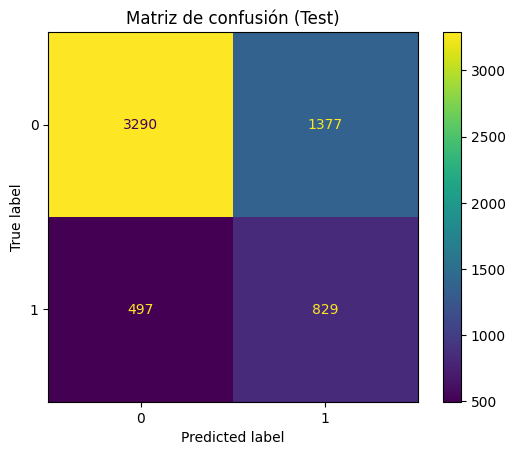

In [ ]:
#Validación Cruzada estratificada con una única partición de los datos
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"F1: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_test.unique())
plt.figure()
disp.plot(values_format="d")
plt.title("Matriz de confusión (Test)")
plt.show()


# Malla de valores

F1 en la clase 1 mide qué tan bien el modelo identifica los defaults, penalizando tanto las falsas alarmas (marcar como riesgoso a alguien que sí iba a pagar) como los defaults que se dejan pasar sin detectar.

Por ello se utiliza esta metrica para identificar el mejor modelo posible,  ya que si se utiliza el promedio entre estas dos (Clase 0 y Clase 1), se obtrendia un numero inflado ya que el datset está desbalanceado debido a que hay mas clientes que se categorizan en la clase 0 a en la clase 1, por lo tanto el criterio de elección estaria sesgado.

Las variables que oscilaran son el numero maximo de iteraciones del solver, para aumentar su capacidad de precision, y el hiperparametro c (inverso de la fuerza de regularización), este controla la intensidad de la penalización aplicada a los coeficientes del modelo para evitar el sobreajuste (overfitting). En sí valores pequeños = más regularización (coeficientes más pequeños); valores grandes = menos regularización (modelo más "libre").

<table>
  <tr>
    <th>Tabla 1 — max_iter = 1000</th>
  </tr>
  <tr>
    <th>C</th>
    <th>F1 clase 1</th>
    <th>Precision</th>
    <th>Recall</th>
  </tr>
  <tr>
    <td>0.001</td>
    <td>0.4710</td>
    <td>0.3770</td>
    <td>0.6275</td>
  </tr>
  <tr>
    <td>0.01</td>
    <td>0.4716</td>
    <td>0.3770</td>
    <td>0.6297</td>
  </tr>
  <tr>
    <td>0.1</td>
    <td>0.4693</td>
    <td>0.3754</td>
    <td>0.6259</td>
  </tr>
  <tr>
    <td>1</td>
    <td>0.4694</td>
    <td>0.3758</td>
    <td>0.6252</td>
  </tr>
  <tr>
    <td>10</td>
    <td>0.4694</td>
    <td>0.3758</td>
    <td>0.6252</td>
  </tr>
  <tr>
    <td>100</td>
    <td>0.4696</td>
    <td>0.3760</td>
    <td>0.6252</td>
  </tr>
</table>



<table>
  <tr>
    <th>Tabla 2 — max_iter = 500</th>
  </tr>
  <tr>
    <th>C</th>
    <th>F1 clase 1</th>
    <th>Precision</th>
    <th>Recall</th>
  </tr>
  <tr>
    <td>0.001</td>
    <td>0.4710</td>
    <td>0.3770</td>
    <td>0.6275</td>
  </tr>
  <tr>
    <td>0.01</td>
    <td>0.4716</td>
    <td>0.3770</td>
    <td>0.6297</td>
  </tr>
  <tr>
    <td>0.1</td>
    <td>0.4693</td>
    <td>0.3754</td>
    <td>0.6259</td>
  </tr>
  <tr>
    <td>1</td>
    <td>0.4694</td>
    <td>0.3758</td>
    <td>0.6252</td>
  </tr>
  <tr>
    <td>10</td>
    <td>0.4694</td>
    <td>0.3758</td>
    <td>0.6252</td>
  </tr>
  <tr>
    <td>100</td>
    <td>0.4696</td>
    <td>0.3760</td>
    <td>0.6252</td>
  </tr>
</table>

<table>
  <tr>
    <th>Tabla 3 — max_iter = 200</th>
  </tr>
  <tr>
    <th>C</th>
    <th>F1 clase 1</th>
    <th>Precision</th>
    <th>Recall</th>
  </tr>
  <tr>
    <td>0.001</td>
    <td>0.4710</td>
    <td>0.3770</td>
    <td>0.6275</td>
  </tr>
  <tr>
    <td>0.01</td>
    <td>0.4716</td>
    <td>0.3770</td>
    <td>0.6297</td>
  </tr>
  <tr>
    <td>0.1</td>
    <td>0.4693</td>
    <td>0.3754</td>
    <td>0.6259</td>
  </tr>
  <tr>
    <td>1</td>
    <td>0.4694</td>
    <td>0.3758</td>
    <td>0.6252</td>
  </tr>
  <tr>
    <td>10</td>
    <td>0.4694</td>
    <td>0.3758</td>
    <td>0.6252</td>
  </tr>
  <tr>
    <td>100</td>
    <td>0.4696</td>
    <td>0.3760</td>
    <td>0.6252</td>
  </tr>
</table>

<h2>Interpretación final modelo<h2>

De la malla, se puede observar:

**De las iteraciones:**
</br>El solver converge mucho antes de agotar el maximo de iteraciones, incluso con el valor mas bajo (200). Las tres tablas son identicas entre si, lo que confirma que aumentar max_iter no le da al modelo margen para mejorar: llega a su optimo antes de necesitar mas iteraciones.

**De el hiperparametro C:**
</br>El desempeño se mantiene practicamente constante en todo el rango explorado, con una metrica F1 que oscila entre 0.4693 y 0.4716. Esa diferencia de 0.002 es tan pequeña que se encuentra dentro del ruido, por lo que ninguna configuracion representa una mejora real sobre las demas. Esto indica que el modelo es robusto frente a este hiperparametro: ni aumentar ni disminuir la regularización cambia su comportamiento de manera significativa.


Por estas razones elegimos el modelo C=1, Max_iter=200, class_weight = "balanced"

C = 1 es el valor por defecto en scikit-learn y no impone una regularización particular en ninguna direccion, mientras que max_iter = 200 es suficiente dado que el solver converge sin problemas. No se justifica elegir un hiperparametro mas extremo cuando las diferencias observadas no son significativas.

**Metricas del modelo final**

F1 - clase 1: 0.4694
</br>Precision - clase 1: 0.3758
</br>Recall - clase 1: 0.6252

El modelo identifica 62% de los clientes que efectivamente incurrirán en impago, pero de todos los que marca como riesgosos, solo el 37% realmente lo son.

En un contexto de riesgo crediticio es preferible marcar de más a algunos clientes solventes (falsos positivos, que solo generan una revisión adicional) que dejar pasar a clientes que sí van a incumplir (falsos negativos, que se traducen en pérdida directa para la entidad).

Por ultimo, la consistencia entre las metricas de validación cruzada (F1 ≈ 0.4765) y las del test final (F1 = 0.4694) confirma que el modelo generaliza bien: no hay señales de sobreajuste y el desempeño observado es una estimacion confiable de lo que se esperaria con datos nuevos.

<h2>Matriz de confusión<h2>

### Interpretación de la matriz de confusión

La matriz de confusión permite ver el detalle de los aciertos y errores del modelo sobre los 5.993 clientes del conjunto de prueba, separando los dos tipos de error según su naturaleza:

- **Verdaderos negativos (3.290):** clientes que pagaron cumplidamente y que el modelo clasificó correctamente como no riesgosos.
- **Verdaderos positivos (829):** clientes que efectivamente incurrieron en impago y que el modelo logró detectar.
- **Falsos positivos (1.377):** clientes solventes que el modelo marcó erróneamente como riesgosos. Es el error más frecuente del modelo.
- **Falsos negativos (497):** clientes que incumplieron y que el modelo no logró detectar. Es el error menos frecuente, pero el más costoso.

De los 1.326 clientes que realmente incurrieron en impago, el modelo identificó 829 (62,52%) y dejó pasar 497 sin detectar. Por otro lado, de los 2.206 clientes que marcó como riesgosos, solo 829 (37,58%) resultaron ser impagos reales.

Finalmente, cabe señalar que la metrica accuracy del modelo es de 68,73%, un valor que no se deberia utilizar dado que el 77,88% de los clientes pertenece a la clase 0.

Un modelo que predijera "no impago" para todos alcanzaría una exactitud superior sin detectar un solo impago. Por esta razón el análisis se centra en las métricas de la clase 1.

# 2. Problema de Regresión







## 2.1 Descripción del dataset: *Automobile*


- **Fuente:** UCI Machine Learning Repository — Dataset ID `10`  
  URL: https://archive.ics.uci.edu/dataset/10/automobile

- **Creador:** Jeffrey Schlimmer (1985)
- **Licencia:** Creative Commons Attribution 4.0 (CC BY 4.0)
- **Donación:** 18 de mayo de 1987
- **Fuente original de los datos:** 1985 Ward's Automotive Yearbook
Observaciones: 205 vehículos
- **Variables:** 25 características disponibles en UCI, con variables categóricas, enteras y continuas. Para este proyecto, normalized-losses será utilizada como variable objetivo y las demás variables seleccionadas como predictoras.
- **Valores faltantes:** Sí, presentes en algunas variables, incluyendo normalized-losses.



##Dominio del Problema:
El problema pertenece al sector asegurador y financiero, específicamente al área de riesgo y pricing actuarial. La base de datos Automobile contiene información sobre características de diferentes vehículos, junto con medidas relacionadas con su riesgo asegurador y sus pérdidas normalizadas. El conjunto cuenta con 205 observaciones y 25 características, incluyendo variables categóricas y numéricas.

##Descripción y Tipo de Problema:
Se trata de un problema de regresión, cuyo objetivo será predecir la variable normalized-losses a partir de las características del vehículo. Esta variable representa el pago promedio relativo por pérdidas por vehículo asegurado durante un año, normalizado dentro de categorías de vehículos de tamaño similar. Por tanto, el modelo buscará estimar un valor numérico continuo asociado con el costo esperado de los siniestros.

##Utilidad e Importancia:
Predecir las pérdidas esperadas permite estimar el nivel de riesgo económico asociado a asegurar un vehículo. Esta información puede utilizarse como apoyo para establecer primas de seguro más adecuadas, ya que vehículos con mayores pérdidas esperadas deberían representar, en principio, un mayor costo para la aseguradora.

Además, es posible que un modelo de este tipo contribuya a mejorar la tarificación de seguros, segmentar los vehículos según su nivel de riesgo, reducir el riesgo de cobrar primas insuficientes y apoyar la gestión de la rentabilidad de una cartera de seguros. De esta manera, la predicción permite relacionar las características del vehículo con el costo esperado de los siniestros y utilizar esta estimación como insumo para la toma de decisiones.

## Relevancia en la Ingeniería Financiera
Este problema es relevante para la Ingeniería Financiera porque combina el análisis de datos, la estadística y Machine Learning con la medición y gestión de riesgos financieros. En este caso, la predicción de normalized-losses permite estimar una variable relacionada con las pérdidas esperadas, un concepto fundamental para evaluar el riesgo económico de una cartera de seguros.

Además, representa una aplicación práctica de los modelos cuantitativos en el sector asegurador, donde la estimación del riesgo y de las pérdidas esperadas es fundamental para el pricing, la gestión de cartera y la sostenibilidad financiera de las aseguradoras.

## 2.2. Carga del dataset real (UCI via Pandas)

In [ ]:
column_names = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
    "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
    "compression-ratio", "horsepower", "peak-rpm", "city-mpg",
    "highway-mpg", "price"
]

data2 = pd.read_csv(
    '/content/Dataset_Automoviles.data',
    header=None,
    names=column_names,
    na_values="?"
)

df2 = data2.copy()
print(f"Dimensiones: {df2.shape}")
df2.head(10)

Dimensiones: (205, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
5,2,NaN,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,15250.0
6,1,158.0,audi,gas,std,four,sedan,fwd,front,105.8,192.7,71.4,55.7,2844,ohc,five,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,17710.0
7,1,NaN,audi,gas,std,four,wagon,fwd,front,105.8,192.7,71.4,55.7,2954,ohc,five,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,18920.0
8,1,158.0,audi,gas,turbo,four,sedan,fwd,front,105.8,192.7,71.4,55.9,3086,ohc,five,131,mpfi,3.13,3.40,8.3,140.0,5500.0,17,20,23875.0
9,0,NaN,audi,gas,turbo,two,hatchback,4wd,front,99.5,178.2,67.9,52.0,3053,ohc,five,131,mpfi,3.13,3.40,7.0,160.0,5500.0,16,22,NaN


# Descripción de las variables

**Symboling**: es el nivel de riesgo asegurado de -3 (seguro) a 3 (riesgoso). Es una variable tipo entero.

**normalized-losses ** es la pérdida promedio de seguro por vehículo al año, normalizada por tamaño de auto. Es una variable tipo float.

**Make ** marca de vehículo (alfa-romero, audi, bmw, chevrolet, dodge, honda,
isuzu, jaguar, mazda, mercedes-benz, mercury, mitsubishi, nissan, peugot, plymouth, porsche, renault, saab, subaru, toyota, volkswagen, volvo). Es una variable objeto

**fuel-type:** es el tipo de combustible,puede ser:  diesel ó gasolina. Es una variable objeto

**Aspiration**: muestra si es motor estándar o turboalimentado. Es una variable Objeto

**num-of-doors:** Indica el número de puertas del vehículo (dos o cuatro). Es una variable Objeto

**body-style:** indica la carroceria; hardtop, wagon, sedan, hatchback, convertible. Es una variable Objeto

**drive-wheels:** muestra el tipo de tracción: 4wd, fwd o rwd. Es una variable objeto

**engine-location:** indica la ubicación del motor; delantero o trasero. Es una variable objeto.

**Wheel-base:** indica la distancia entre ejes. Es una variable tipo float

**length:** indica la  longitud total. Es una variable tipo float

**width:** indica el ancho.  Es una variable tipo float

**Height:** indica la altura. Es una variable tipo float.

**Curb-Weight:** muestra el peso en vacío. Es una variable tipo entero

**Engine-type: **muestra la configuración del motor (dohc, ohc, rotor, etc.). Es una variable objeto

**Num of cylinders:**indica el número de cilindros (2 a 20). Es una variable objeto

**Engine size:** muestra la cilindrada del motor. Es una variable tipo entero.

**Fuel system: **indica el sistema de alimentación (carburador, inyección). Es una variable objeto.

**Bore:** mide el diámetro del cilindro. Es una variable tipo float


**Stroke:** es la carrera del pistón. Es una variable tipo float
Compression ratio: muestra la  relación de compresión.  Es una variable tipo float

**Horsepower:** indica los caballos de fuerza.  Es una variable tipo float  

**Peak rpm:** muestra las  revoluciones máximas. Es una variable tipo float

**City mpg: **indica el rendimiento en ciudad. Es una variable tipo entero.

**Highway mpg**: indica el rendimiento en carretera. Es una variable tipo entero.

**Price:** indica el precio del vehículo. Es una variable tipo float



## 2.3. Inspección inicial y limpieza básica

In [ ]:
# Tipos de datos y conteo de nulos
info = pd.DataFrame({
    "dtype": df2.dtypes.astype(str),
    "n_nulls": df2.isna().sum(),
    "n_unique": df2.nunique()
}).sort_index()

display(info)
display(df2.describe())

,dtype,n_nulls,n_unique
aspiration,object,0,2
body-style,object,0,5
bore,float64,4,38
city-mpg,int64,0,29
compression-ratio,float64,0,32
curb-weight,int64,0,171
drive-wheels,object,0,3
engine-location,object,0,2
engine-size,int64,0,44
engine-type,object,0,7


,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,164.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [ ]:
# Limpieza mínima: eliminar duplicados exactos si existieran
n_before = len(df2)
df2 = df2.drop_duplicates()
n_after = len(df2)
print(f"Filas eliminadas por duplicados: {n_before - n_after}")
df2.head()

Filas eliminadas por duplicados: 0


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


1. **Normalized losses: ** Cuenta con 164 registros, es decier, presenta 41 valores faltantes. Esta variable oscila entre un mínimo de 65 y un máximo de 256, representando la pérdida promedio de seguro por vehículo-año normalizada por tamaño de auto. El promedio es de 122, con una desviación estandar de 35.44, lo que refleja una dispersión moderada.

2. ** Symboling:** cuenta con 295 registros, sin valores faltantes. La variable oscila entre un mínimo de -2 y un máximo de 3. El promedio es de 0.83, con una desviación estandar de 1.25, lo que indica que la mayoría de los autos se ubica en un nivel de riesgo moderado a ligeramente positivo.

3. Wheel-base: Cuenta con 205, sin valores faltantes. La distancia entre ejes oscila entre un mínimo de 86.6 y un máximo de 120.9 pulgadas. El promedio es de 98.76, con una desviación estandar de 6.02.

4. Lenght: Cuenta con 205, sin valores faltantes. La longitud de los vehículos oscila entre un 141.1 y 208.1. El promedio de longitud 174.05, con una desviación estandar de 12.34, mostrando una dispersión moderada-baja  en el tamaño de los autos.


5. Width: Cuenta con 205, sin valores faltantes. El ancho mínimo de los vehículos oscila entre un mínimo de 60.3 y un máximo de 72.3. El promedio es 65.91, con una desviación de 2.15, evidenciando muy poca dispersión: los vehiculos tienden a tener anchos bastante homogéneos.

6. Heigth:Cuenta con 205, sin valores faltantes. La altura oscila entre 47.8 y 59.8. El promedio es de 53.72 con una desviación de 2.44, lo que indica una baja dispersión.

7. Curb-weight: Cuenta con 205, sin valores faltantes. El peso en vacío oscila entre un mínimo 1488 y un máximo de 4066. El promedio es de 2555.57, con una desviación estandar de 520.68, lo que refleja una dispersión considerable en el paso en vacío de los vehículos.

8. Engine Size: Cuenta con 205, sin valores faltantes.El tamaño del motor oscila entre 61  y 326. El promedio es de 126.91 con una desviación de 0.27.

9. Bore: cuenta con 203, es decir, tiene dos valores faltantes.  El díametro del cilindro oscila entre 2.54 y 3.94. El promedio es de 3.33 on una desviación estandar de 0.27


10. Stroke: cuenta con 201 registros, es decir, tiene 4 valores faltantes. La carrera del pistón oscila 2.07 y 4.17. El promedio es de 3.26 con una desviación estandar de 0.32.

11. Compression ratio:  Cuenta con 205, sin valores faltantes. La relación de compresión oscila entre un mínimo de 7 y un máximo de 23. El promedio es de 10.14 con una desviación de 3.97, lo que indica una alta dispersión, influida por la diferencia entre motores a gasolina y diesel

12. Horsepower: cuenta con 203, es decir, tiene dos valores faltantes. Los caballos de fuerza oscilan entre 48 y 288. El promedio es de 104.26 con una desviación de 39.71 evidenciando la variedad de motores.

13. Peak rpm: cuenta con 203, es decir, tiene dos valores faltantes. Las revoluciones oscilan entre 4150 y 6600. El promedio es de 5125.37 con una dispersión de 479.33.

14. City mpg:Cuenta con 205, sin valores faltantes. El rendimiento en la ciudad el vehículo oscila entre 13 y 49 mpg. El promedio es de 25.22 con una desviación estandar de 6.543

15.Highway mpg:Cuenta con 205, sin valores faltantes. El rendimiento en carretera del vehículo oscila entre 16 y 54 mpg. El promedio es de 30.75 con una desviación de 6.89.

16. Price:  Cuenta con 201 registros, con 4 valores faltantes. El precio de los vehículos oscila entre un mínimo de 5118 y un máximo de 45400. El promedio es de 13.207 con una desviación estandar de 7.947, lo que indica una dispersión muy alta, esto podría indicar que vehículos de alta gama elevan el promedio por encima del valor típico.



### Imputación de Valores Nulos

In [ ]:

variables_numericas = df2.select_dtypes(include=["int64", "float64"]).columns
variables_categoricas = df2.select_dtypes(include=["object"]).columns

# Imputación variables numéricas con la media
for columna in variables_numericas:
    df2[columna] = df2[columna].fillna(df2[columna].mean())

# Imputación variables categóricas con la moda
for columna in variables_categoricas:
    df2[columna] = df2[columna].fillna(df2[columna].mode()[0])

# Verificar que no queden valores nulos
print("Valores nulos después de la imputación:")
display(df2.isna().sum())

Valores nulos después de la imputación:


,0
symboling,0
normalized-losses,0
make,0
fuel-type,0
aspiration,0
num-of-doors,0
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


## 2.4. Análisis Exploratorio de Datos (EDA)

### 2.4.1 Distribuciones de variables (histogramas)

In [ ]:
# Variable objetivo
target2 = "normalized-losses"

# Variables categóricas
objetc_cols = [
    "aspiration",
    "body-style",
    "drive-wheels",
    "engine-location",
    "engine-type",
    "fuel-system",
    "fuel-type",
    "make",
    "num-of-cylinders",
    "num-of-doors"
]

# Variables numéricas: todas las demás, excepto las categóricas y la variable objetivo
numeric_cols2 = [
    col for col in df2.columns
    if col not in objetc_cols
]

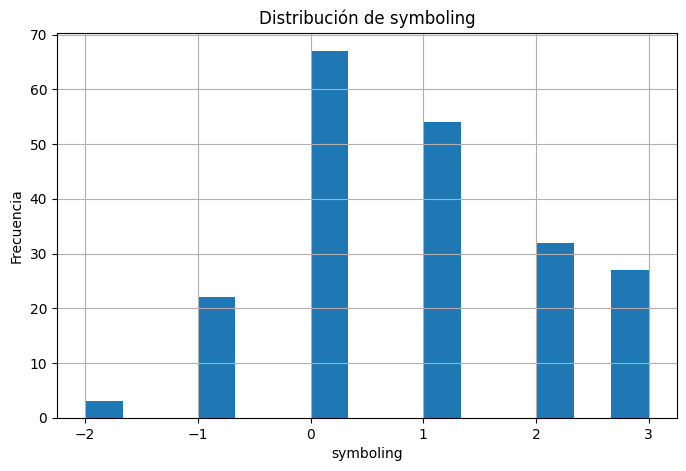

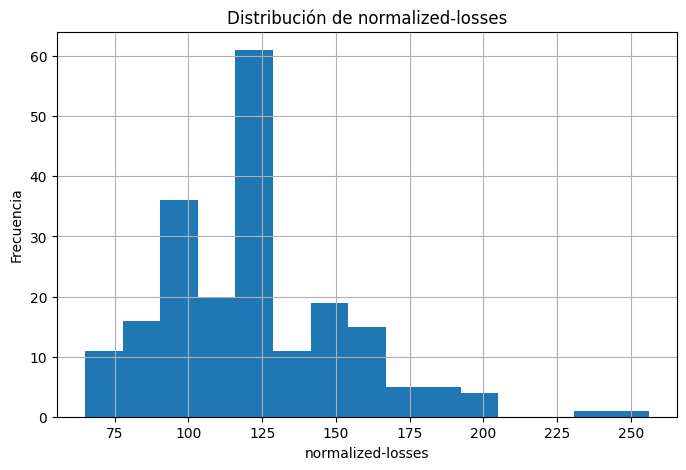

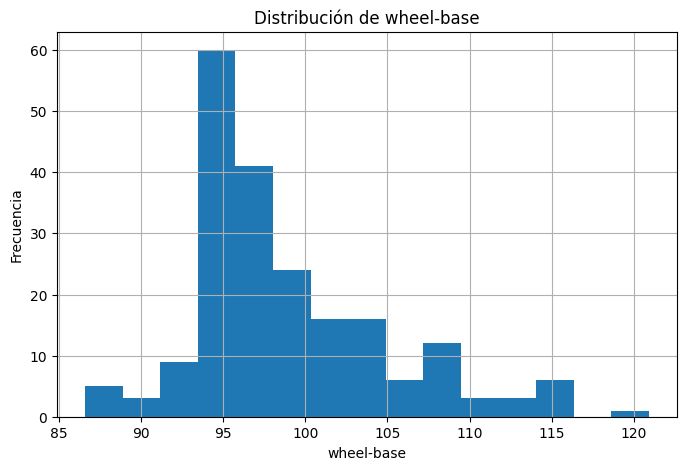

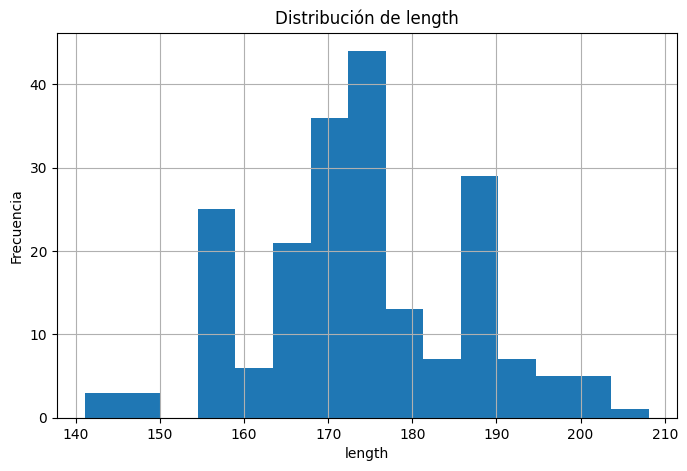

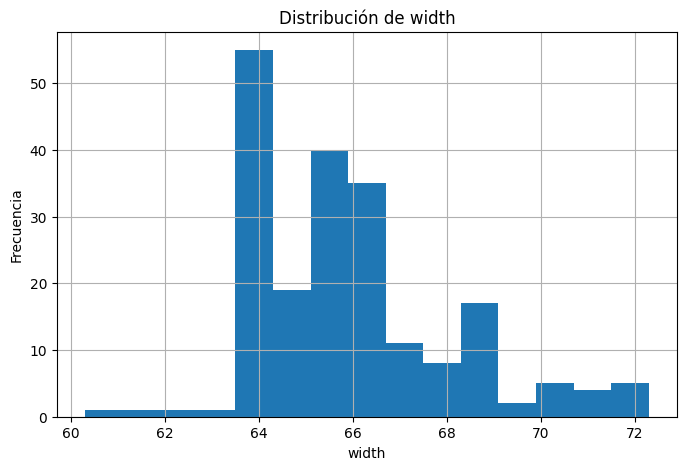

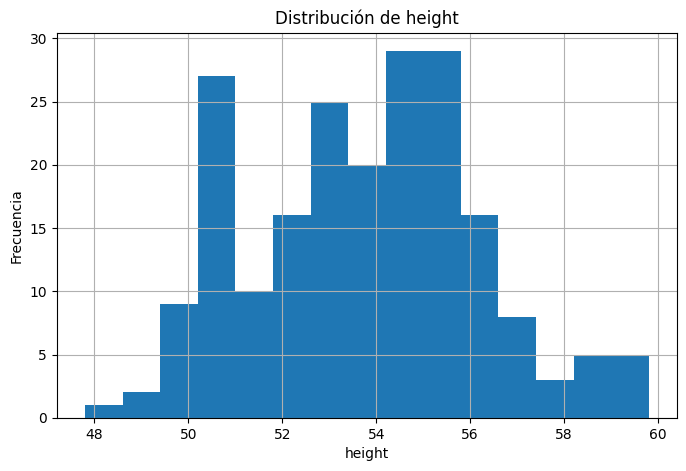

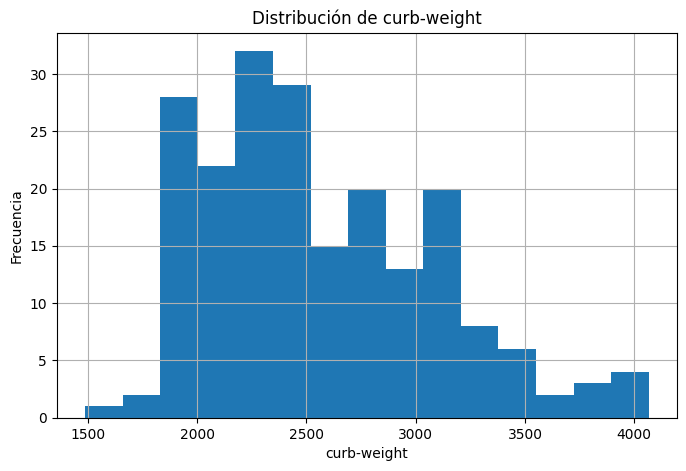

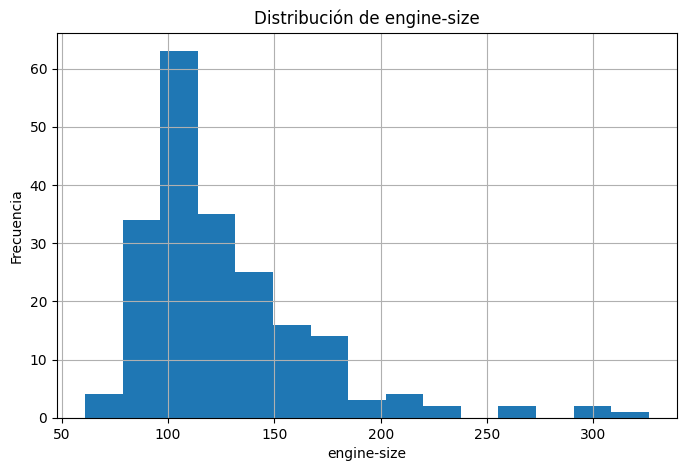

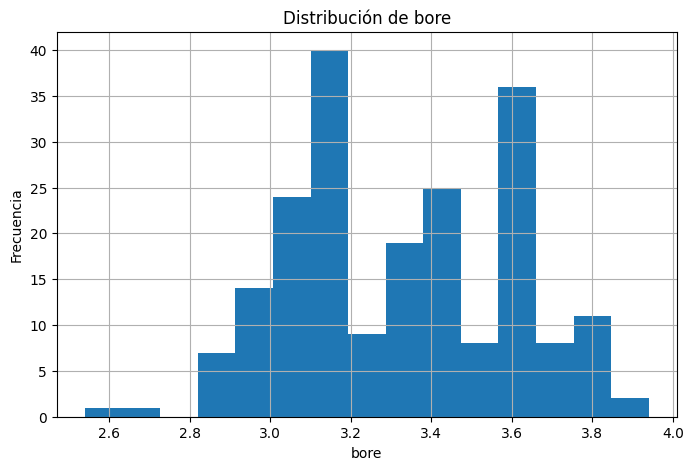

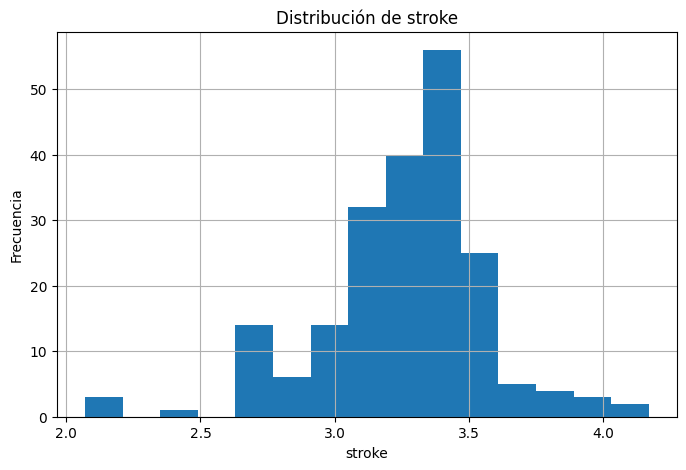

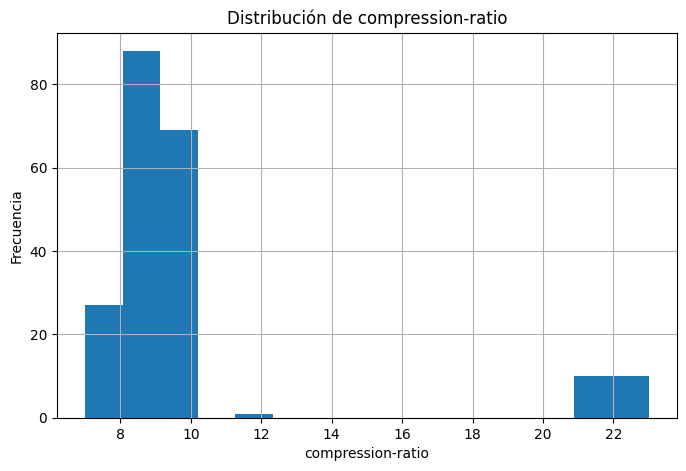

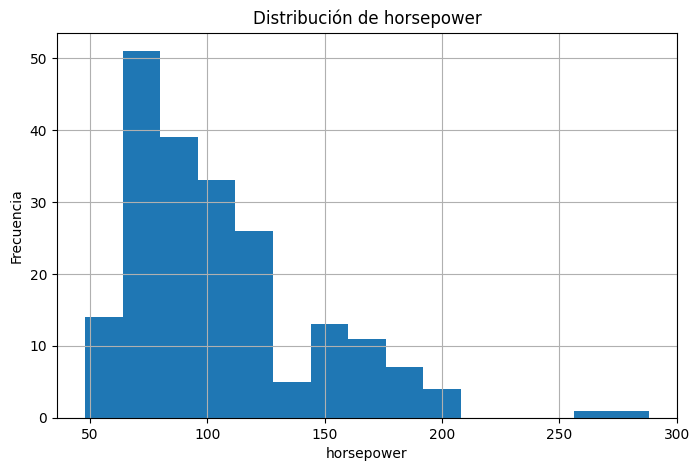

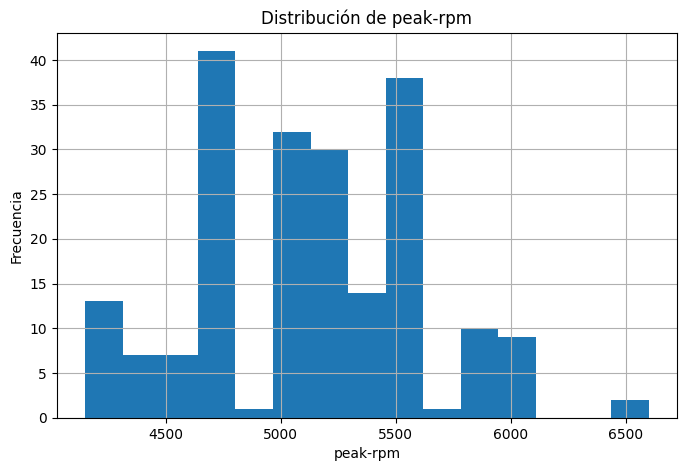

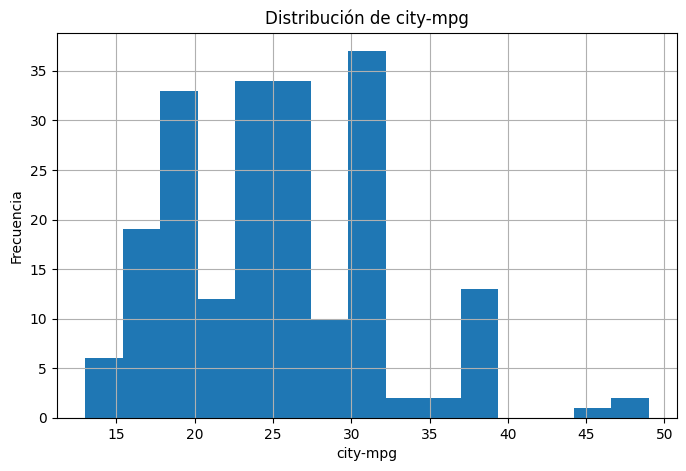

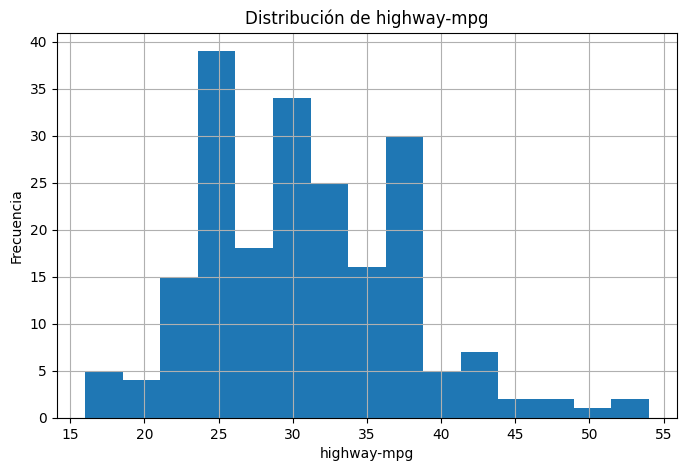

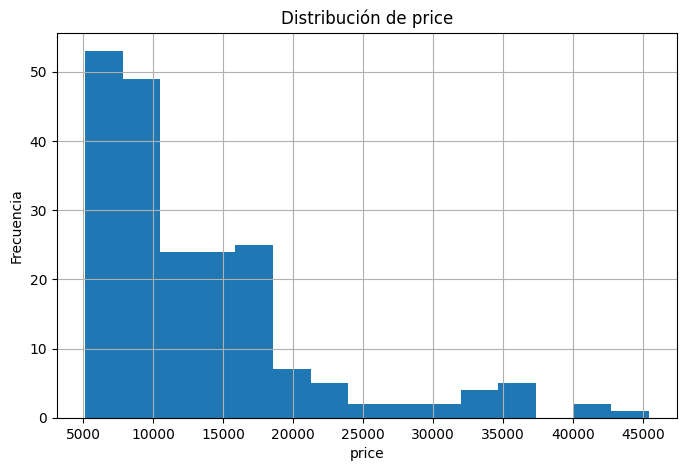

In [ ]:
for col in numeric_cols2:
    plt.figure(figsize=(8, 5))

    df2[col].hist(bins=15)

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.ticklabel_format(style='plain', axis='x')

    plt.show()

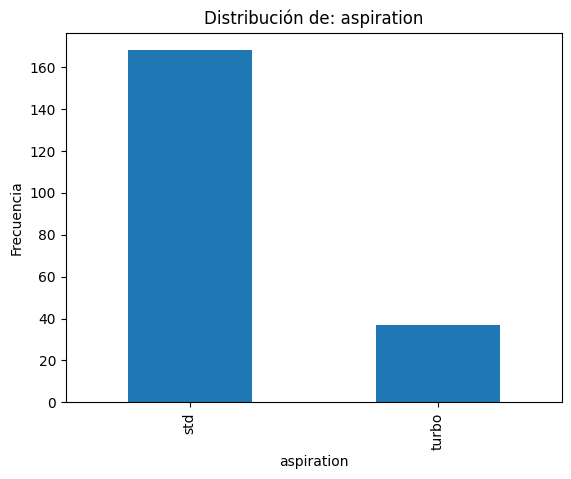

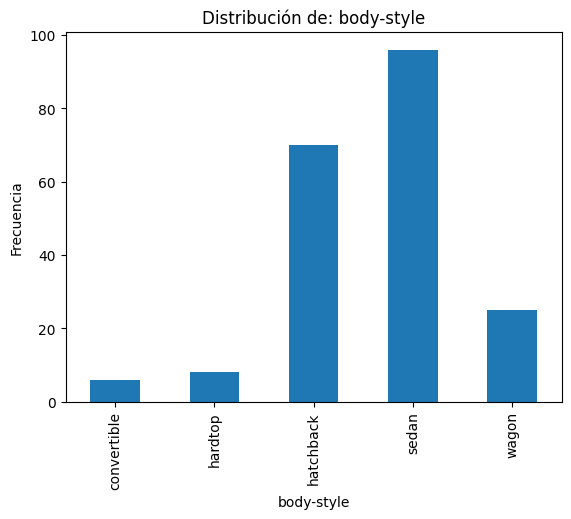

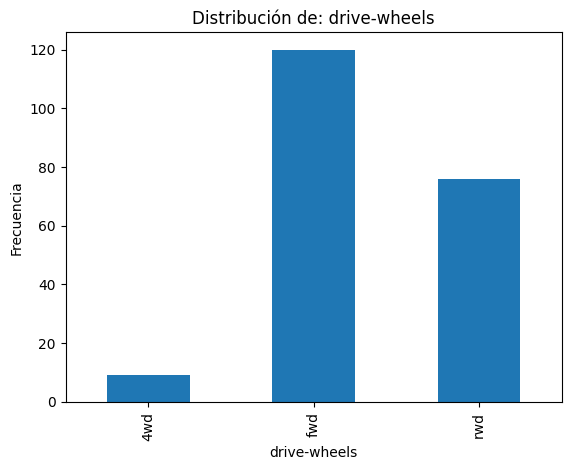

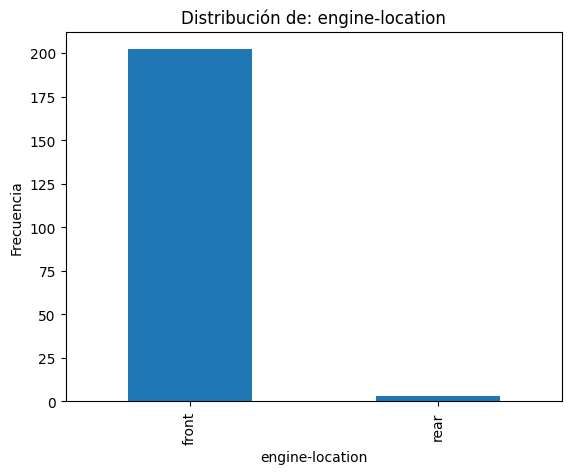

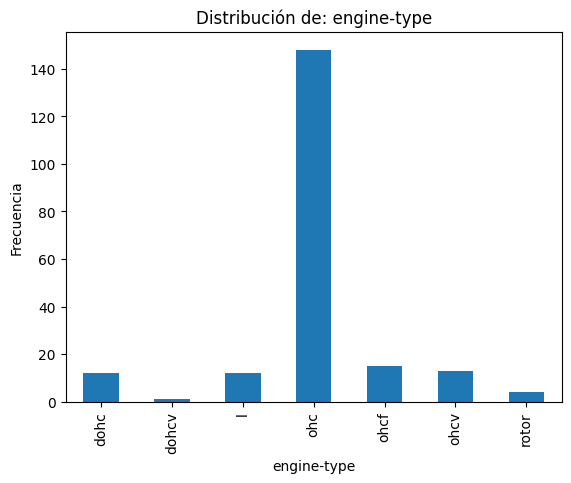

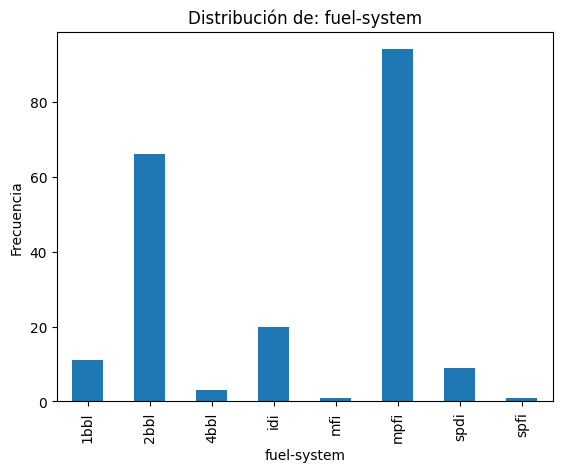

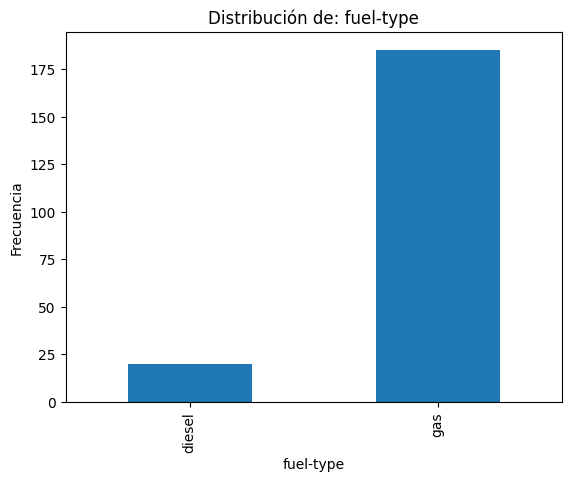

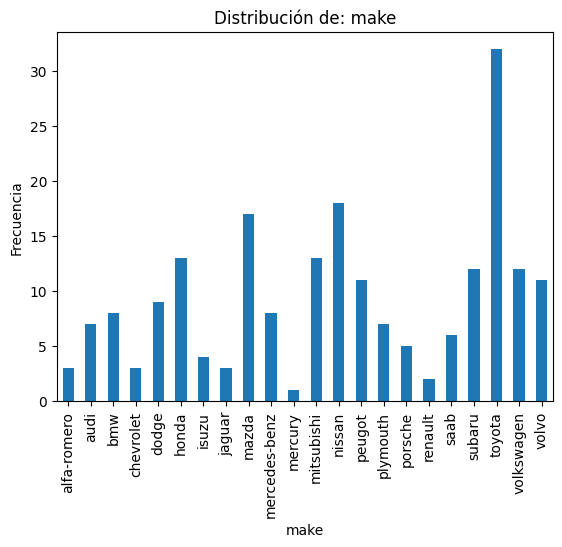

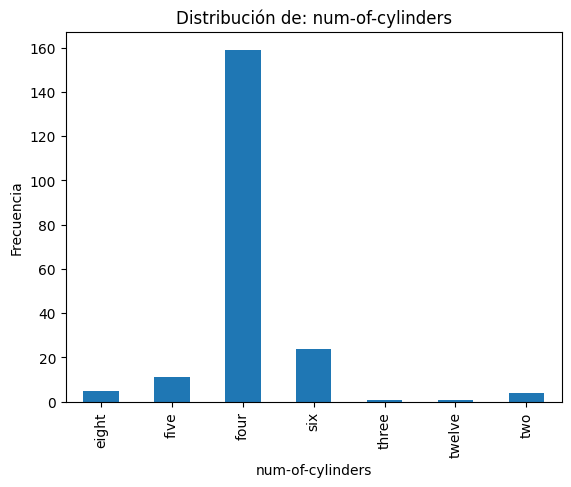

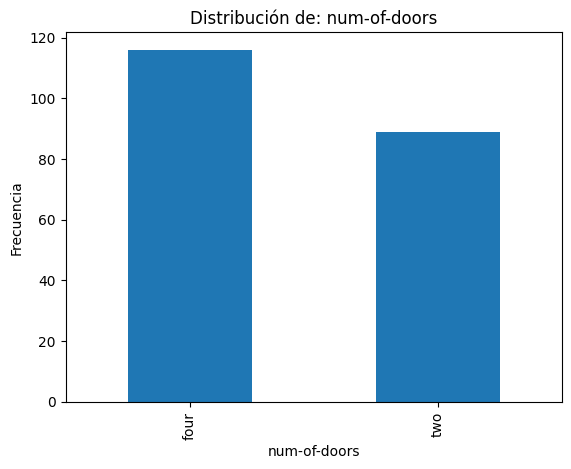

In [ ]:
for col in objetc_cols:
    plt.figure()
    df2[col].value_counts().sort_index().plot(kind="bar")
    plt.title(f"Distribución de: {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

### 2.4.2 Diagramas de caja (detectar posibles outliers)

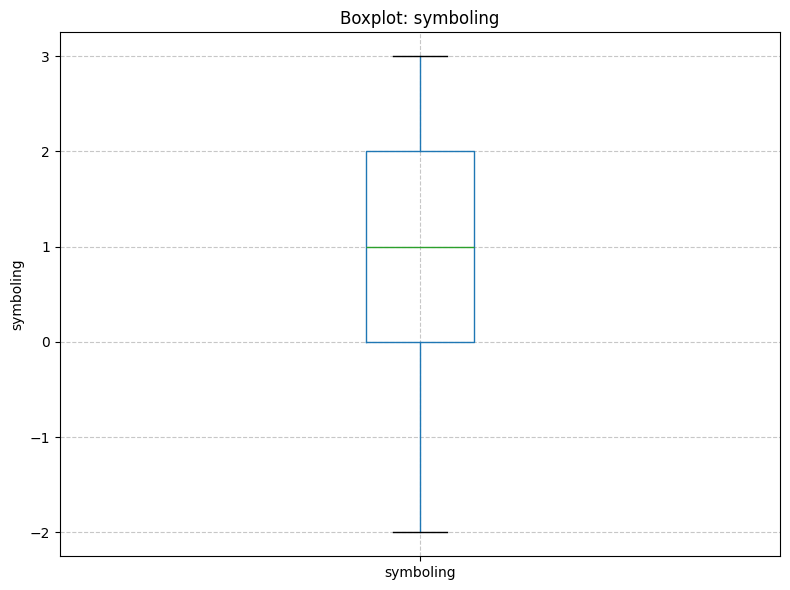

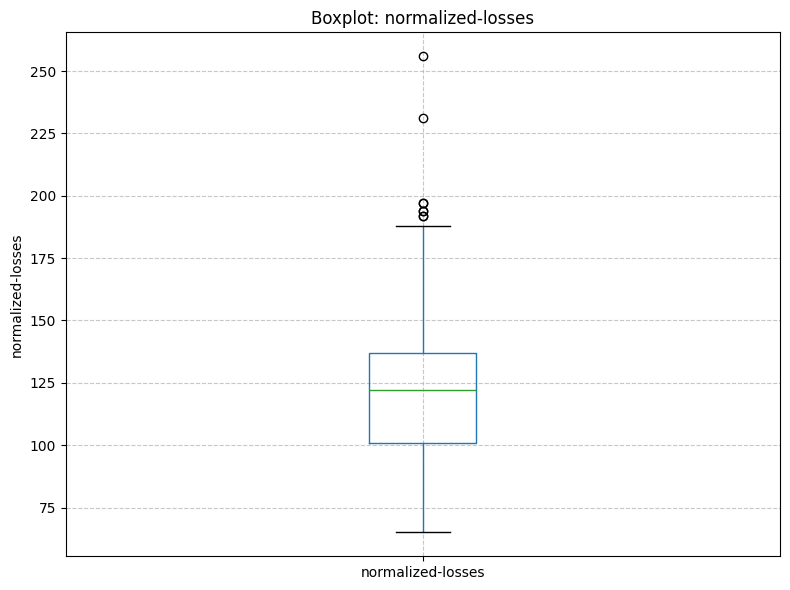

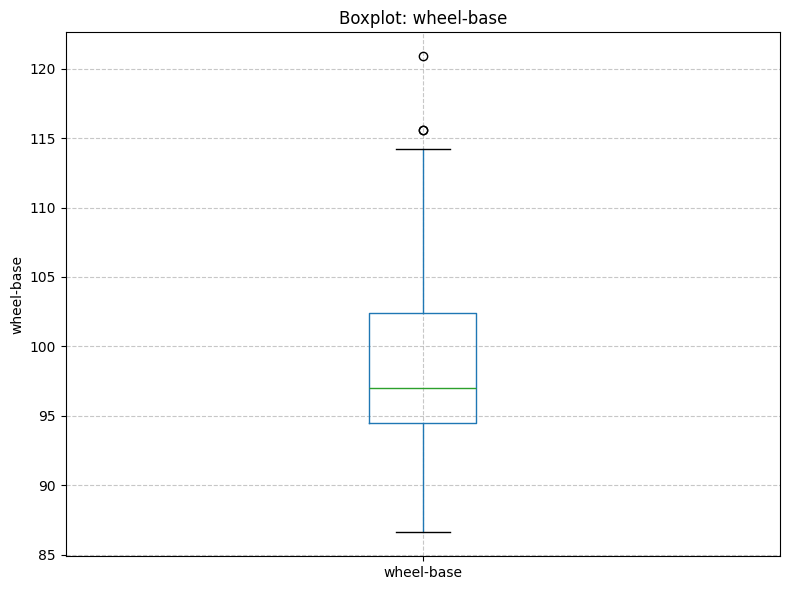

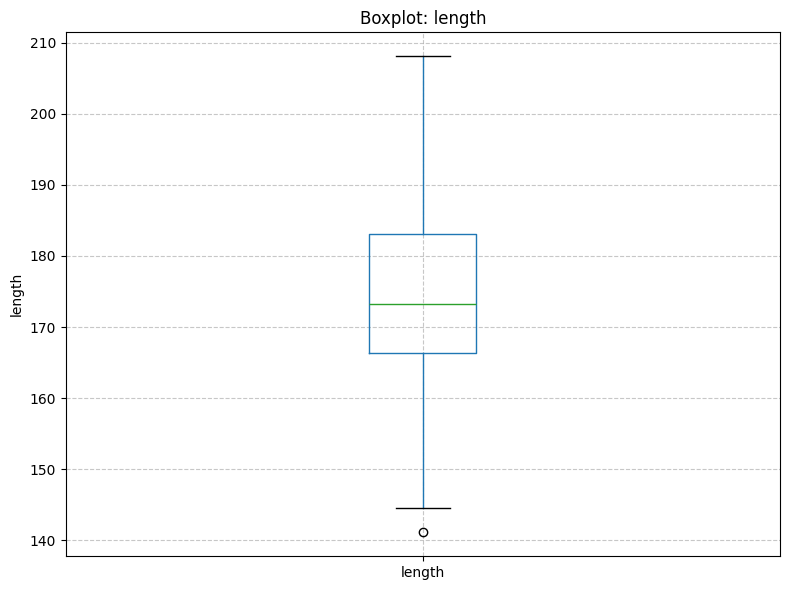

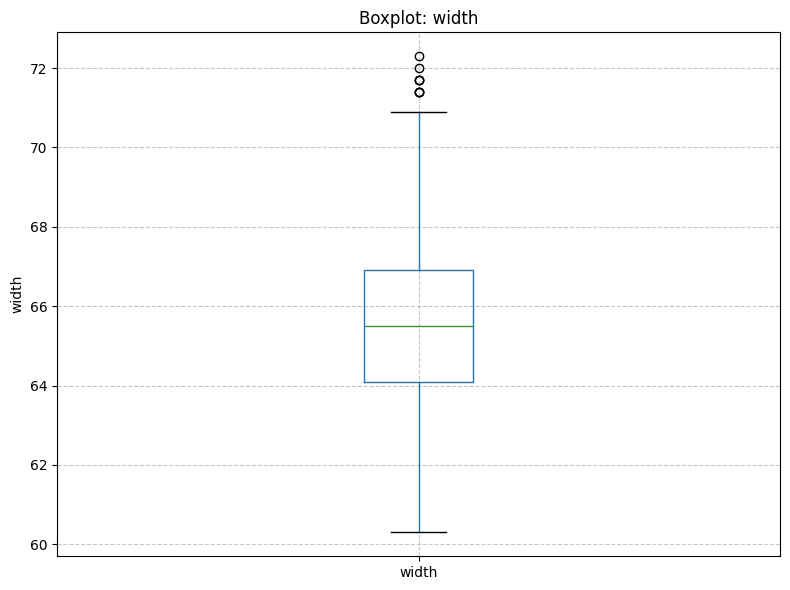

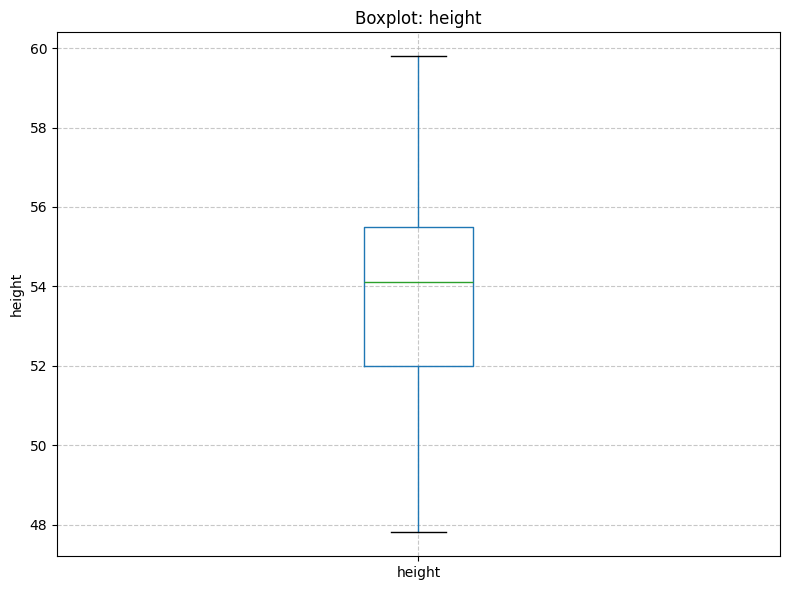

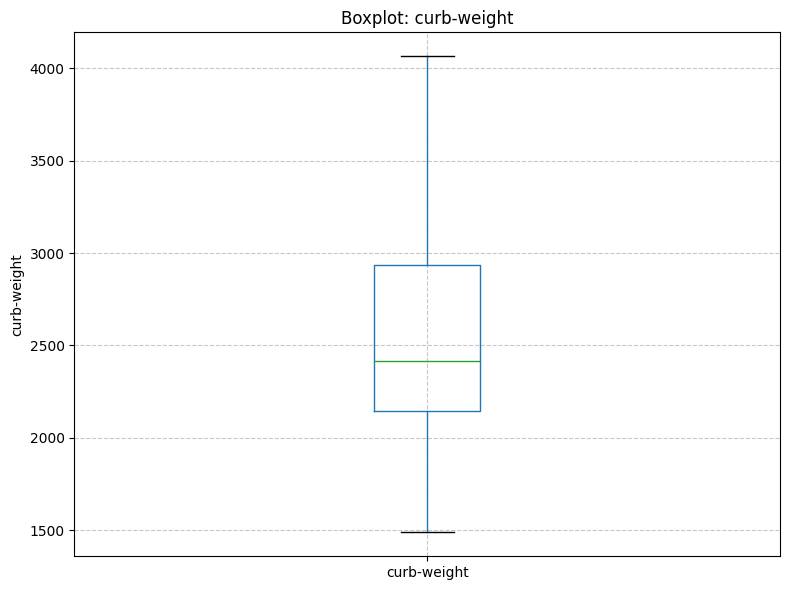

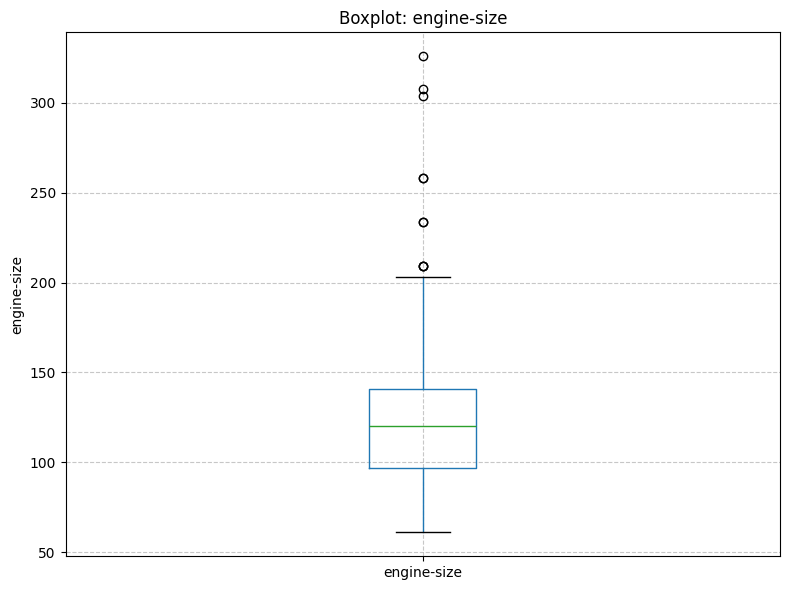

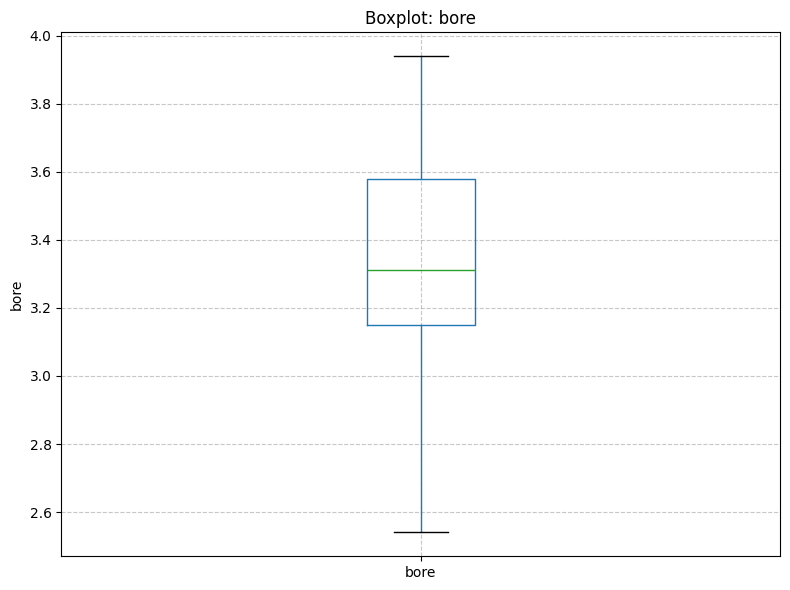

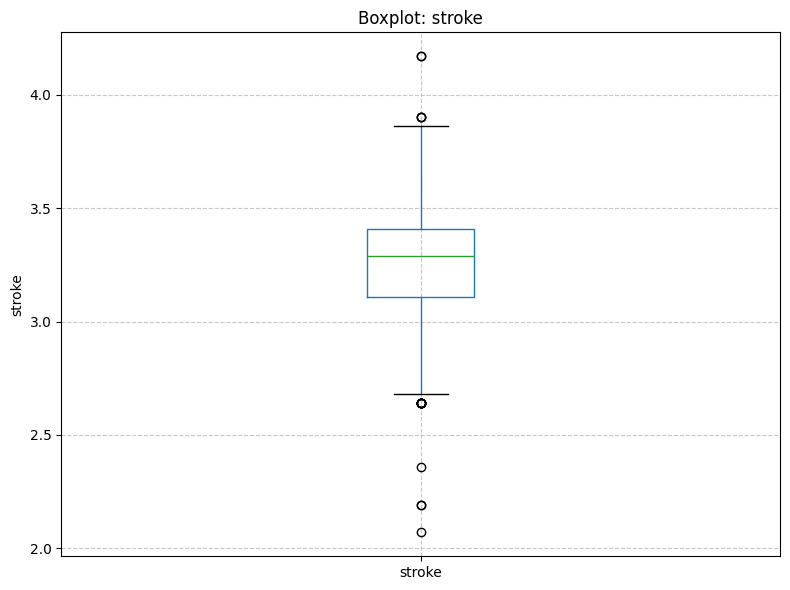

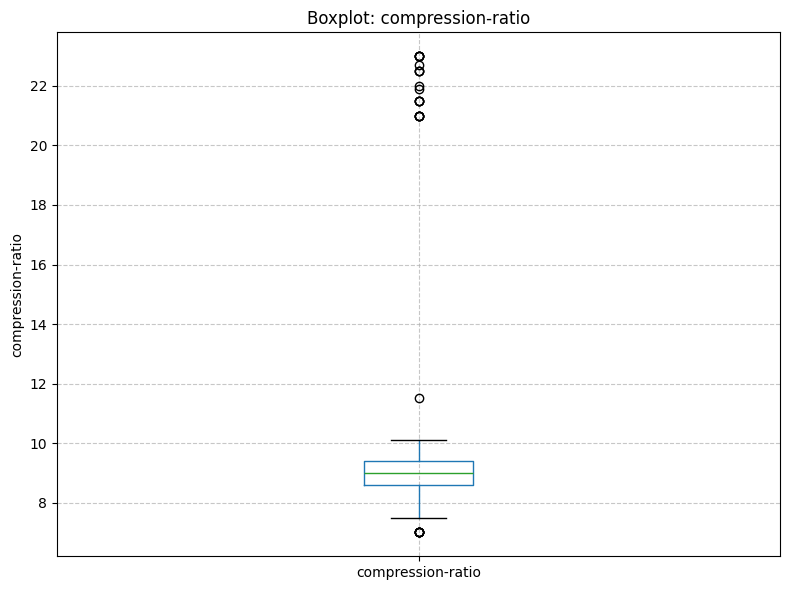

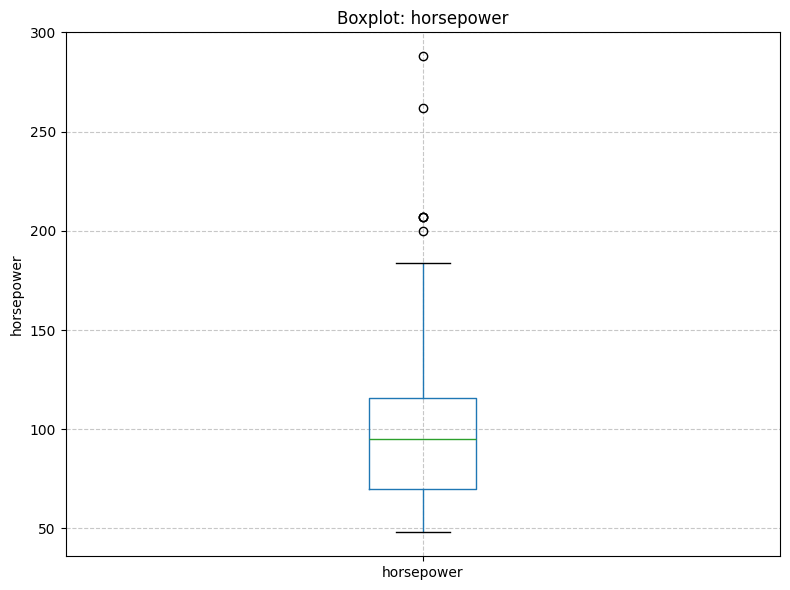

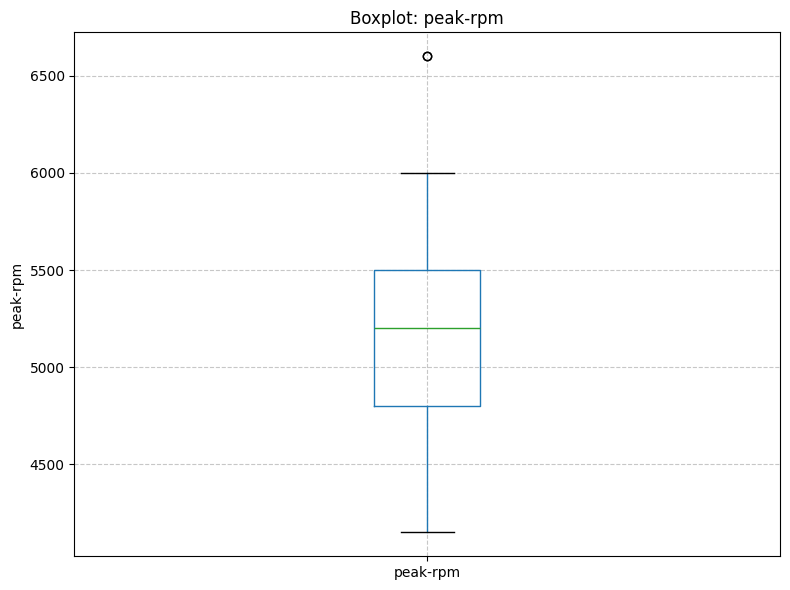

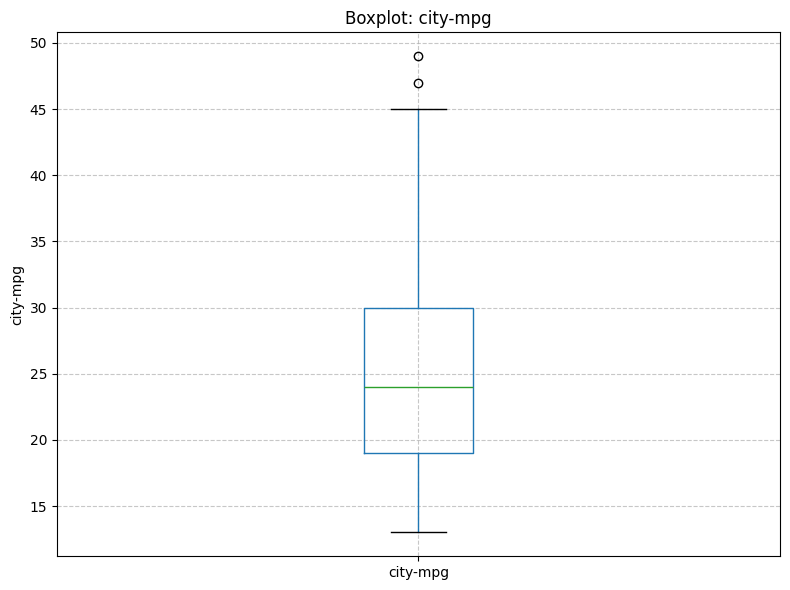

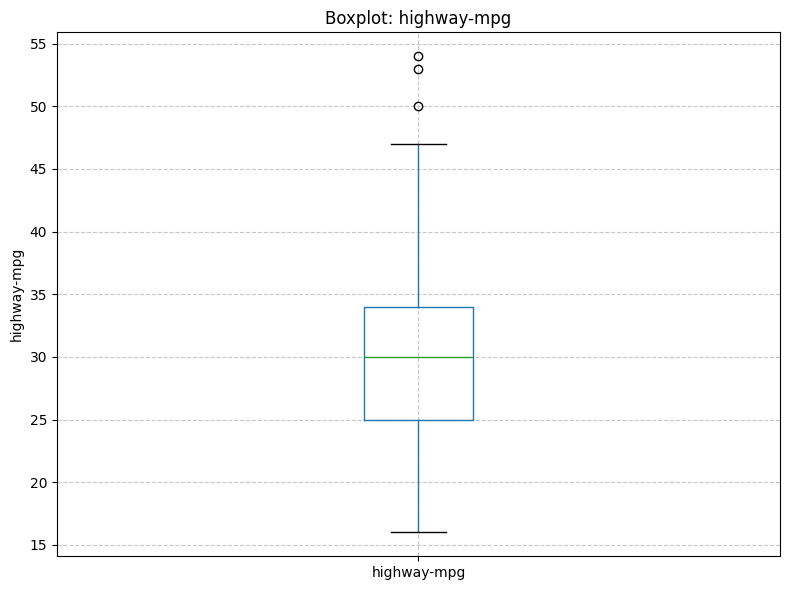

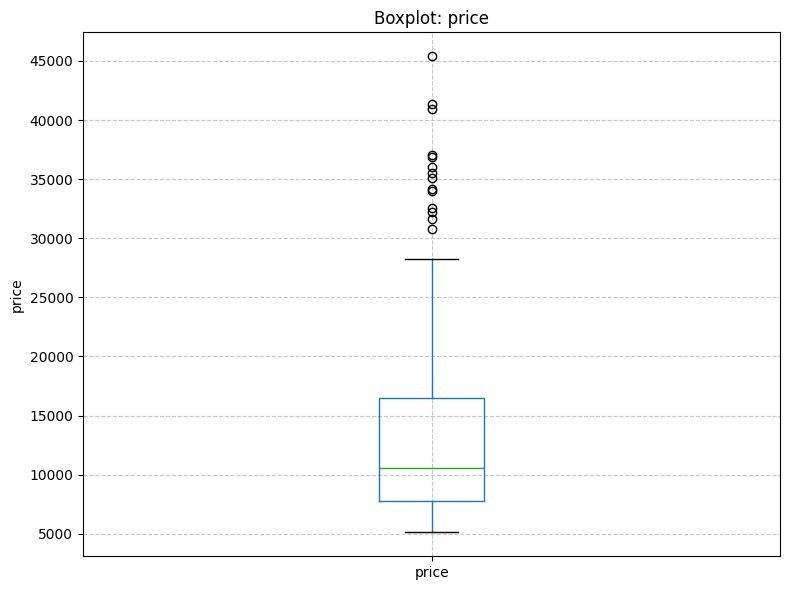

In [ ]:
for col in numeric_cols2:
    plt.figure(figsize=(8, 6))
    df2.boxplot(column=col)
    plt.title(f"Boxplot: {col}")
    plt.ylabel(col)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

###Interpretación de las variables numéricas:
- **normalized-losses:** La mayoría de los vehículos presenta pérdidas esperadas alrededor de valores medios, aunque algunos muestran costos esperados de siniestros considerablemente más altos, identificados como valores atípicos.

- En cuanto a las dimensiones de los vehículos **(wheel-base, length, width y height):** La mayoría de los automóviles tiene dimensiones similares y se concentra en tamaños intermedios. Sin embargo, aparecen algunos vehículos más grandes o más pequeños de lo habitual, principalmente en wheel-base y width.

- En cuanto al peso de los vehículos **(curb-weight):** Predominan vehículos de peso bajo o intermedio, mientras que unos pocos son considerablemente más pesados. Se observan algunos valores atípicos superiores.

- En cuanto a las características del motor **(engine-size, bore, stroke, compression-ratio y horsepower):** La mayoría de los vehículos cuenta con motores de características moderadas. Sin embargo, existen algunos vehículos con motores considerablemente más grandes, mayor potencia o relaciones de compresión mucho más altas, generando valores atípicos, especialmente en engine-size, compression-ratio y horsepower. Stroke también presenta algunos valores inusualmente bajos y altos.

- **peak-rpm:** La mayoría de los motores alcanza su potencia máxima dentro de un rango similar, aunque existen algunos vehículos con revoluciones máximas inusualmente altas.

- Consumo de combustible **(city-mpg y highway-mpg):** La mayoría de los vehículos presenta un rendimiento intermedio de millas por galón. Algunos vehículos recorren una cantidad considerablemente mayor de millas con un galón de combustible, por lo que aparecen como valores atípicos superiores.

- **price:** La mayor parte de los vehículos tiene precios relativamente bajos o intermedios, mientras que unos pocos son considerablemente más costosos, lo que genera varios valores atípicos superiores.

### Interpretación de las variables categóricas:

- **"fuel-type", "aspiration" y "engine-location"** (Tipo de combustible, aspiración y ubicación del motor): Predomina claramente un tipo de vehículo; principalmente aquellos que utilizan gasolina, tienen aspiración estándar y cuentan con el motor ubicado en la parte delantera.

- En cuanro a características generales **("body-style", "drive-wheels" y "num-of-doors"):** Predominan ciertos tipos de carrocería y sistemas de tracción, especialmente los vehículos con tracción delantera o trasera. En cuanto al número de puertas, las categorías de dos y cuatro puertas presentan cantidades relativamente similares.

- En las características del motor **(engine-type, fuel-system y num-of-cylinders): Existe una clara concentración en algunos tipos de motor y sistemas de combustible. Destacan especialmente los vehículos con cuatro cilindros, mientras que vehículos con más cilindros son mucho menos frecuentes.

- **"make":** Los vehículos pertenecen a una amplia variedad de marcas, aunque algunas tienen una presencia considerablemente mayor que otras.

- **"symboling":** Los vehículos se concentran principalmente en determinados niveles de riesgo, especialmente alrededor de los valores 0 y 1, mientras que los niveles más extremos son menos frecuentes.

### 4.3 Matriz de correlación (mapa de calor)

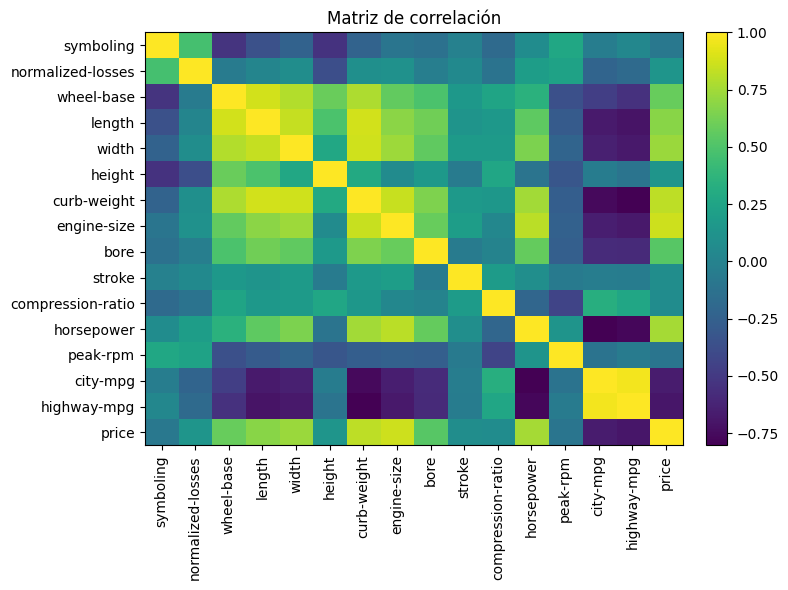

In [ ]:
corr2 = df2[numeric_cols2].corr(numeric_only=True)

plt.figure(figsize=(8,6))
im = plt.imshow(corr2, aspect='auto', interpolation='nearest')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Matriz de correlación")
plt.xticks(ticks=np.arange(len(numeric_cols2)), labels=numeric_cols2, rotation=90)
plt.yticks(ticks=np.arange(len(numeric_cols2)), labels=numeric_cols2)
plt.tight_layout()
plt.show()

A partir de la matriz de correlación se logra evidenciar que hay varios grupos de variables con una colinealidad extremadamente alta, que por consiguiente, brindan información redundante.

Teniendo en cuenta esto, se deciden eliminar las siguientes variables:

- "wheel-base" (Distancia entre ejes) porque presenta una multicolinealidad estructural extrema. En la matriz de correlación, esta muestra una correlación cercana a 0.80 y 0.90 con las variables "length" y "width".

- "length" (Longitud) está profundamente correlacionada con las dos variables mencionadas anteriormente, mostrando tonos amarillos y verdes muy claros.

Físicamente, un auto con mayor distancia entre ejes es, por definición, un auto más largo y ancho. Por lo que se decide conservar únicamente la variable "width" para no introducir información idéntica al modelo

También se eliminaron del modelo:

- "curb-weight" (Peso vehicular) ya que es la variable que más correlaciones severas acumula en todo el dataset. Tiene una correlación casi perfecta con la longitud, el ancho y el tamaño del motor (engine-size). Al eliminarla, permitimos que variables individuales más específicas (como width para la estructura y engine-size/horsepower para la potencia mecánica) expliquen el riesgo sin distorsionar los errores estándar.

- "highway-mpg" (Rendimiento en carretera) debido a que presenta colinealidad perfecta con la variable city-mpg. Ambas variables miden exactamente el mismo fenómeno físico: la eficiencia energética. Al conservar únicamente city-mpg, se retiene toda la información sobre el consumo de combustible sin duplicarla. Se decide trabajar con city-mpg porque desde el enfoque actuarial, el manejo urbano suele ser un mejor predictor de siniestralidad que el de carretera (principalmente por factores como frenados constantes, tráfico pesado,etc.)



In [ ]:
df2['engine-location'].value_counts()

,count
engine-location,
front,202
rear,3


 Al ejecutar un conteo de frecuencia de la variable "engine-location", se observa un gran desbalance entre clases, dado que 202 vehículos tienen el motor en la parte frontal (front) y únicamente 3 lo tienen en la parte trasera (rear). Estadísticamente, esta variable presenta una varianza casi nula. Un predictor tan masivamente desbalanceado no aporta información matemática útil al algoritmo para discriminar o generalizar el comportamiento de los siniestros; por el contrario, incluirlo obligaría al modelo a calcular un coeficiente basado en solo 3 observaciones, generando un sesgo y un riesgo de sobreajuste. Por lo que tambipen se decide eliminar esta variable

Por último, la variable "symboling" no representa una característica física del vehículo, sino un índice de riesgo calculado previamente a partir del comportamiento histórico de los siniestros.

Al depender directamente de la propia variable objetivo (normalized-losses), incluírla generaría multicolinealidad por construcción y alteraría el propósito del modelo, que es estimar el costo de los siniestros basándose puramente en las especificaciones técnicas del automóvil.

In [ ]:
df2.drop(columns=["symboling", "wheel-base", "engine-location", "highway-mpg", "curb-weight", "length"], inplace=True)
df2.head()

,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,width,height,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,price
0,122.0,alfa-romero,gas,std,two,convertible,rwd,64.1,48.8,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,13495.0
1,122.0,alfa-romero,gas,std,two,convertible,rwd,64.1,48.8,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,16500.0
2,122.0,alfa-romero,gas,std,two,hatchback,rwd,65.5,52.4,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,16500.0
3,164.0,audi,gas,std,four,sedan,fwd,66.2,54.3,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,13950.0
4,164.0,audi,gas,std,four,sedan,4wd,66.4,54.3,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,17450.0


Matriz de correlación con las variables finales

In [ ]:
# Variable objetivo
target3 = "normalized-losses"

# Variables categóricas
objetc_cols1 = [
    "aspiration",
    "body-style",
    "drive-wheels",
    "engine-type",
    "fuel-system",
    "fuel-type",
    "make",
    "num-of-cylinders",
    "num-of-doors"
]

# Variables numéricas: todas las demás, excepto las categóricas y la variable objetivo
numeric_cols3 = [
    col for col in df2.columns
    if col not in objetc_cols
]

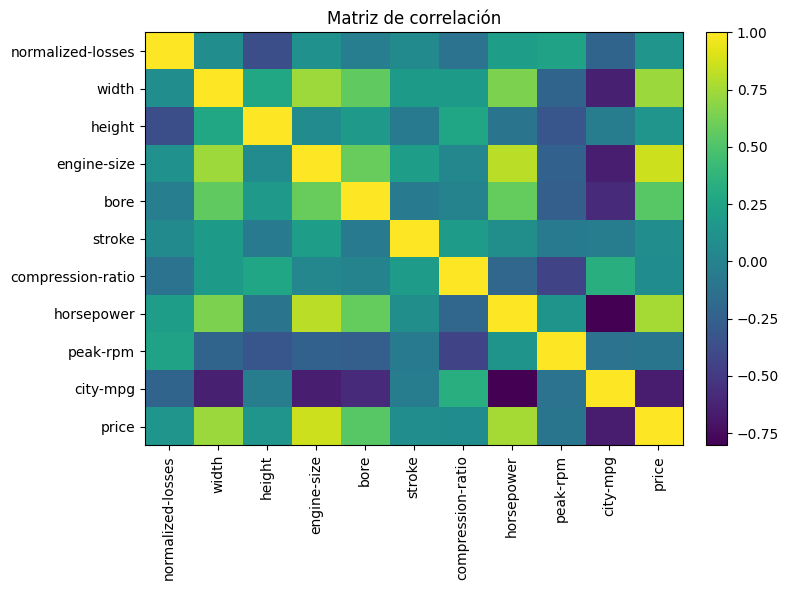

In [ ]:
corr3 = df2[numeric_cols3].corr(numeric_only=True)

plt.figure(figsize=(8,6))
im = plt.imshow(corr3, aspect='auto', interpolation='nearest')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Matriz de correlación")
plt.xticks(ticks=np.arange(len(numeric_cols3)), labels=numeric_cols3, rotation=90)
plt.yticks(ticks=np.arange(len(numeric_cols3)), labels=numeric_cols3)
plt.tight_layout()
plt.show()

Se evidencia que las variables restantes son ideales para el modelo porque la mayoría de sus intersecciones muestran tonos verdes intermedios y azulados, lo que indica que no tienen correlaciones altas ni repetidas entre sí tras haber eliminado los excesos del inicio. Cada variable que quedó aporta información visualmente distinta sobre las características de los vehículos; tales como: tamaño del auto, potencia, consumo, etc.

La nueva matriz demuestra que el conjunto de datos está prácticamente listo para que el modelo aprenda a predecir normalized-losses de forma estable.

**<h4>Transformacion de las variables categoricas<h4>**

Los modelos de regresión lineal solo pueden trabajar con variables numéricas, por lo que las categóricas restantes en el dataset, por lo que se transformarán las variables categoricas con el objetivo de ser utilizadas y tener mas información en la estimación del modelo, esto se va a realizar con la metodología One-Hot encoding, esta metodologia en sintesis crea una columna binaria (0/1) por cada categoría posible, para darles un valor numerico y tomar cada una de ellas como categorias que aportan a dar explicaciones al modelo.

In [ ]:
# Reducir dimensionalidad, se agruparan marcas con muy pocas observaciones

conteo_marcas = df2["make"].value_counts()
marcas_raras = conteo_marcas[conteo_marcas < 5].index
print(f"Marcas agrupadas en 'otras': {list(marcas_raras)}")

df2["make"] = df2["make"].replace(marcas_raras, "otras")
print(f"\nCategorías de 'make' después de agrupar: {df2['make'].nunique()} (antes: 22)")

Marcas agrupadas en 'otras': []

Categorías de 'make' después de agrupar: 17 (antes: 22)



Antes de realizar esta metodologia se reduce la dimensionalidad de la variable make, ya que es una variable categorica de alta cardinalidad, contiene 22 categorías distintas. Al aplicar One-Hot Encoding, cada categoría se convierte en una columna binaria adicional, lo que se traduce en 21 nuevos parámetros que el modelo debe estimar.

Esto se puede ver como un problema ya que hay variables con muy pocas observaciones (Menos de 5 casos) el coeficiente es mas ruido de estas variables que un patron real del efecto de estas marcas.

Como solución a este problema agrupamos todas las marcas con < 5 observaciones en una categoria común llamada "otras", con el objetivo de reducir el número de parámetros a estimar sin descartar información, asi las marcas poco frecuentes contribuyen colectivamente a través de un único coeficiente compartido.

In [ ]:
# Conversión de variables categóricas a numéricas (One-Hot Encoding)
df2_encoded = pd.get_dummies(df2, columns=objetc_cols1, drop_first=True)

# Asegurar que las columnas dummy queden como enteros (0/1) y no booleanos
dummy_cols = [c for c in df2_encoded.columns if c not in df2.columns]
df2_encoded[dummy_cols] = df2_encoded[dummy_cols].astype(int)

print(f"Dimensiones antes de codificar: {df2.shape}")
print(f"Dimensiones después de codificar: {df2_encoded.shape}")
df2_encoded.head()

Dimensiones antes de codificar: (205, 20)
Dimensiones después de codificar: (205, 55)


,normalized-losses,width,height,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,price,aspiration_turbo,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon,drive-wheels_fwd,drive-wheels_rwd,engine-type_dohcv,engine-type_l,engine-type_ohc,engine-type_ohcf,engine-type_ohcv,engine-type_rotor,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi,fuel-type_gas,make_bmw,make_dodge,make_honda,make_mazda,make_mercedes-benz,make_mitsubishi,make_nissan,make_otras,make_peugot,make_plymouth,make_porsche,make_saab,make_subaru,make_toyota,make_volkswagen,make_volvo,num-of-cylinders_five,num-of-cylinders_four,num-of-cylinders_six,num-of-cylinders_three,num-of-cylinders_twelve,num-of-cylinders_two,num-of-doors_two
0,122.0,64.1,48.8,130,3.47,2.68,9.0,111.0,5000.0,21,13495.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
1,122.0,64.1,48.8,130,3.47,2.68,9.0,111.0,5000.0,21,16500.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
2,122.0,65.5,52.4,152,2.68,3.47,9.0,154.0,5000.0,19,16500.0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
3,164.0,66.2,54.3,109,3.19,3.40,10.0,102.0,5500.0,24,13950.0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,164.0,66.4,54.3,136,3.19,3.40,8.0,115.0,5500.0,18,17450.0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


De esta forma se realiza la metodologia, creando columnas binarias con variables dummie, asi llevando nuestras variables categoricas a informacion para el modelo de regresión lineal.

Es importante notar tambien que el parametro drop_first = "True" se realiza con el objetivo de eliminar la primera variable, ya que puede ser explicada como 1 menos las demas, esto es colinealidad perfecta, desestabilizando el modelo, con el objetivo de que no suceda esto se utiliza este parametro, eliminando redundancia del modelo sin perder información

In [ ]:
from sklearn.linear_model import LinearRegression

# Se dejan como DataFrame (NO .to_numpy()) para que el ColumnTransformer
# pueda seguir usando los nombres de las columnas más adelante.
X = df2_encoded.drop(columns=["normalized-losses"])
y = df2_encoded["normalized-losses"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42

)

numeric_features = X_train.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_features)],
    remainder="drop"
)

reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", LinearRegression())
])

reg

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['width', 'height',
                                                   'engine-size', 'bore',
                                                   'stroke',
                                                   'compression-ratio',
                                                   'horsepower', 'peak-rpm',
                                                   'city-mpg', 'price',
                                                   'aspiration_turbo',
                                                   'body-style_hardtop',
                                                   'body-style_hatchback',
                                                   'body-style_sedan',
                                                   'body-style_wagon',
                                                   'drive-wheels_fwd',
                                                   'drive-wheels_rwd',
                                                   'engine-type_dohcv',
                                                   'engine-type_l',
                                                   'engine-type_ohc',
                                                   'engine-type_ohcf',
                                                   'engine-type_ohcv',
                                                   'engine-type_rotor',
                                                   'fuel-system_2bbl',
                                                   'fuel-system_4bbl',
                                                   'fuel-system_idi',
                                                   'fuel-system_mfi',
                                                   'fuel-system_mpfi',
                                                   'fuel-system_spdi',
                                                   'fuel-system_spfi', ...])])),
                ('regressor', LinearRegression())])

A diferencia del problema de clasificación, aquí el split no es estratificado, la estratificación solo aplica cuando la variable objetivo es categórica (para mantener la proporción de clases). Como "normalized-losses" es una variable continua, no existen estas clases que preservar. por ello no se usa "stratify". La división sigue siendo 80% entrenamiento / 20% prueba, garantizando que el modelo no vea información del test durante el entrenamiento (evitando fuga de información).

El encadenamiento de pasos queda entonces: imputa medianas -> escala -> regresión lineal. Esto asegura que el proceso sea metodológicamente correcto y reproducible, tal como en el pipeline de clasificación.

In [ ]:
#Se creara la función gradiente descendiente para poder modificar las iteraciones y el parametro Eta
from numpy._core.fromnumeric import transpose
#Error cuadrático medio (criterio para el modelo de regresión polinomial)
def ECM(Y_est,Y):
    N = np.size(Y)
    ecm = np.sum((Y_est - Y)**2)/(2*N)
    return ecm

#Modelo Regresión Múltiple
def regression(X, W):
    Yest = np.dot(X,W)    #con np.dot se realiza el producto matricial. Aquí X es dim [Nxd] y W es dim [dx1]
    return Yest           #La variable Yest contiene la salida de f(X,W)


#Potencia de polinomio
def potenciaPolinomio(X,grado):
    """
    Este método permite aumentar la matriz (base de datos de entrenamiento)
    de tal manera que se incluyan los términos con potencia mayores que 1
    de acuerdo al parámetro grado (M) que pase el usuario.
    """
    X2 = X

    if grado != 1:
        for i in range(2,grado+1):
            Xadd = X**i
            X2 = np.concatenate((X2, Xadd), axis=1)

    return X2


#Gradiente descendente para regresión polinomial
def gradiente_descendente(X,Y,grado,eta,iterations):

    """
    params:
    X: base de datos de entrenamiento (array de numpy)
    Y: variable de salida (array de numpy)
    grado: grado del polinomi (Natural mayor o igual a 1)
    eta: tasa de aprendizaje para el algoritmo de gradiente descendente
    (real mayor que cero. Ej: 0.001)
    iterations: número de iteraciones del algoritmo de gradiente descendente
    """

    #Se modifica la matriz de datos original de acuerdo al grado del polinomio ingresado para el modelo
    X = potenciaPolinomio(X,grado)

    #X es la matriz de datos extendida. W es el vector de parámetros del modelo
    #Extendemos la matriz
    unos = np.array([np.ones(np.size(X,0))])
    #Concatenamos el vector de unos con la matriz X
    X = np.concatenate((unos.T, X), axis=1)
    X = X.reshape(np.size(X,0),np.size(X,1))

    Y = Y.reshape(np.size(Y), 1)

    #Tomamos el número de variables del problema
    d = np.size(X,1)

    #Tomamos el número de muestras de la base de datos
    N = np.size(X,0)

    #Inicializamos el vector de parámetros aleatoriamente
    Want = np.zeros(d)
    Want = Want.reshape(np.size(Want),1)

    eta = eta

    iteraciones = iterations
    ecms = np.zeros(iteraciones)

    for iter in range(iteraciones):

        error = ECM(regression(X,Want),Y)
        ecms[iter] = error

        #Aquí debe completar el código con la regla de actualización de los
        #parámetros W. Tenga en cuenta los nombres de las variables ya creadas:
        #Want, X, Y
        W = Want.T - (eta/N)*(np.dot((np.dot(X,Want) - Y).T,X))
        Want = W.T

        #Nota: si usa la notación matricial esto puede hacerse en dos líneas de
        #código.




    print ('Vector de parámetros del modelo:\n')
    print (W)
    print ('\nError Final = ' + str(np.min(ecms)))

    #Aquí debe completar el código para realizar la gráfica de ecms vs. iteraciones
    #ecms en el eje de las ordenadas (vertical); iteraciones en el eje de las abscisas.

    plt.plot(ecms)
    plt.title('ECM vs Iteraciones')
    plt.xlabel('Iteraciones')
    plt.ylabel('ECM')
    plt.show()

    return W

Vector de parámetros del modelo:

[[ 1.23554878e+02  1.92674752e+00 -1.57713978e+01  1.60341773e+00
  -2.49128658e+00  1.89027491e+00 -1.35909140e+01 -4.11743801e+00
   9.60955617e+00 -6.43593312e+00 -1.41332701e+00 -7.95782552e-01
   1.39936635e+00  8.73050059e+00  1.11952786e+01  6.19874156e+00
  -7.74906875e+00  8.70789002e+00 -4.32923040e+00 -3.37137517e+00
  -2.69451354e-01 -1.14005900e+01 -2.32616490e-02 -3.11007117e+00
  -4.67847703e+00 -2.07044138e+00  6.24581184e+00 -1.25460064e+00
  -8.12787789e+00 -8.56064937e+00 -2.63265919e+00 -6.24581184e+00
  -4.48406804e+00 -1.18957118e+01 -2.50051433e+01 -1.36414838e+01
  -8.56787808e+00 -9.03423903e+00 -1.13366535e+01 -2.14176625e+01
  -3.37137517e+00 -1.05152049e+01 -7.38275690e+00 -5.15805895e+00
  -5.08188554e+00 -2.32912152e+01 -8.43768894e+00 -1.91373182e+01
  -5.32332555e+00  1.91622800e+00  2.39635923e+00  0.00000000e+00
  -2.38730260e+00 -3.11007117e+00  6.48959097e+00]]

Error Final = 143.82308351375767


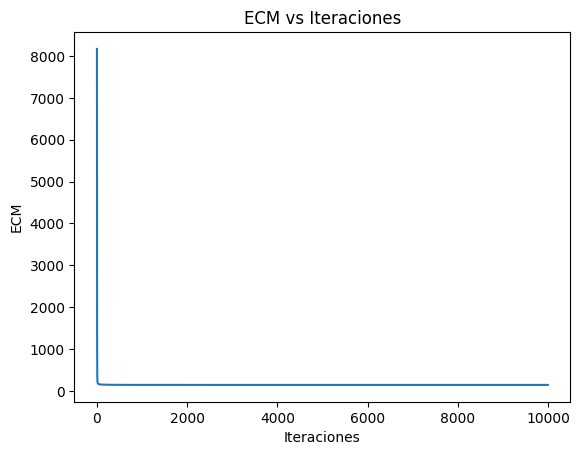

In [ ]:
#Aplicar el pipeline sobre X_train
X_train_scaled = preprocess.fit_transform(X_train)

# Convertir y_train
y_train_arr = y_train.to_numpy()

eta = 0.235
grado = 1

W = gradiente_descendente(X_train_scaled, y_train_arr, grado, eta, 10000)

# Malla de valores

Se decide realizar la malla de valores cambiando la tasa de aprendizaje y las simulaciones, con el objetivo de identificar el mínimo error cuadrático medio (ECM). Se decidió no variar el grado del polinomio debido a la gran cantidad de variables.

# Malla de valores con diferentes eta y 1000 simulaciones


<table>
  <tr>
    <th>Tasa de aprendizaje</th>
    <th>Grado del polinomio</th>
    <th>Error Cuadrático Medio (ECM)</th>
  </tr>
    
 <tr>
    <td>0.1</td>
    <td>1</td>
    <td>145.7808</td>
  </tr>
  <tr>
    <td>0.15</td>
    <td>1</td>
    <td>144.90557</td>
  </tr>
  <tr>
    <td>0.18</td>
    <td>1</td>
    <td>144.6367</td>
  </tr>
  <tr>
    <td>0.19</td>
    <td>1</td>
    <td>144.569758</td>
  </tr>
  <tr>
    <td>0.20</td>
    <td>1</td>
    <td>144.5111</td>
  </tr>
  
  <tr>
    <td>0.22</td>
    <td>1</td>
    <td>144.413774</td>
  </tr>
  <tr>
    <td>0.23</td>
    <td>1</td>
    <td>144.37308</td>
  </tr>
  <tr>
    <td>0.235</td>
    <td>1</td>
    <td>144.35438</td>
  </tr>
  <tr>
    <td>0.24</td>
    <td>1</td>
    <td>239.1702</td>
  </tr>

  </tr>
</table>



Para este primer ejercicio de malla de valores, se realizaron 1.000 simulaciones utilizando un modelo lineal de grado 1, todo esto, para predecir la variable objetivo: normalized-losses. Como resultado se evaluó el desempeño del modelo a partir del error cuadrático medio (ECM) bajo diferentes tasas de aprendizaje.

Se evidenció que a medida que incrementamos la tasa de aprendizaje de 0.1 a 0.235 el ECM disminuye de forma progresiva (de 145.78 a 144. 35). Esto indica que a partir de las simulaciones realizadas, el algoritmo de gradiente descendente logra acercarse más al mínimo de la función de costos utilizando pasos más grandes, ya que recorre una mayor distancia en el mismo número de iteraciones.

Sin embargo, al aumentar la tasa de aprendizaje hasta 0.24, el ECM se incrementa a 239.17. Esto sugiere que se ha superado el límite de estabilidad del algoritmo con pasos demasiado grandes


# Malla de valores con diferentes eta y 10.000 simulaciones

<table>
  <tr>
    <th>Tasa de aprendizaje</th>
    <th>Grado del polinomio</th>
    <th>Error Cuadrático Medio (ECM)</th>
  </tr>
    
 <tr>
    <td>0.1</td>
    <td>1</td>
    <td>143.8376</td>
  </tr>
  <tr>
    <td>0.15</td>
    <td>1</td>
    <td>143.8246</td>
  </tr>
  <tr>
    <td>0.18</td>
    <td>1</td>
    <td>143.8234</td>
  </tr>
  <tr>
    <td>0.19</td>
    <td>1</td>
    <td>143.8233</td>
  </tr>
  <tr>
    <td>0.20</td>
    <td>1</td>
    <td>143.8232</td>
  </tr>
  
  <tr>
    <td>0.22</td>
    <td>1</td>
    <td>143.8231</td>
  </tr>
  <tr>
    <td>0.23</td>
    <td>1</td>
    <td> 143.82309</td>
  </tr>
  <tr>
    <td>0.235</td>
    <td>1</td>
    <td>143.82308</td>
  </tr>
  <tr>
    <td>0.236</td>
    <td>1</td>
    <td>144.35076</td>
  </tr>
  <tr>
    <td>0.25</td>
    <td>1</td>
    <td>450.4507</td>
  </tr>
</table>


Ahora bien, al aumentar el número de simulaciones de 1.000 a 10.000, se obtiene un ECM mucho más estrecho entre 143.82 y 143.82 para tasas de aprendizaje entre 0.1 y 0.235. Esto indica que el algoritmo converge de forma similar al mínimo de la función de costos (ECM). A su vez, se evidencia que el valor mínimo del ECM encontrado con las 10.000 iteraciones (143.82)  es mucho menor al encontrado con 1.000 (144.35), lo que sugiere que aún para ese número de iteraciones no se había alcanzado aún el óptimo. Por último se identifica que el algoritmo presenta inestabilidad con tasas de aprendizaje iguales a 0.236, tasa ligeramente menor al del ejercicio de arriba.



**<h4>Interpretacion final del modelo<h4>**



Primero aclarar que no se varia el grado del polinomio debido a la gran cantidad de variabes que tiene nuestro modelo, subir el grado significa un severo sobreajuste y una inestabilidad mas grande de lo que ya puede ser de lo que ya es por la alta cardinalidad de make. Mantener grado 1 prioriza la estabilidad numérica y la interpretabilidad de los coeficientes.

De la malla de aprendizaje se puede ver que para 1,000 simulaciones, el ECM disminuye de forma progresiva a medida que eta crece de 0.1 a 0.235 (de 145.78 a 144.35): pasos más grandes permiten que el gradiente descendente recorra más distancia hacia el mínimo en el mismo número de iteraciones. Con 10,000 simulaciones, el ECM converge a un rango mucho más estrecho (143.82 – 143.82) para prácticamente todo el rango de eta probado. Esto confirma que con 1,000 iteraciones el algoritmo aún no había llegado al óptimo. Por lo tanto nuestro modelo final es:

eta = 0.235
</br> 10,000 simulaciones
</br> grado = 1

Alcanza el ECM más bajo observado en toda la malla (143.82308) manteniéndose dentro de la zona estable — es el punto más cercano al límite de divergencia (0.236).
